In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
import random

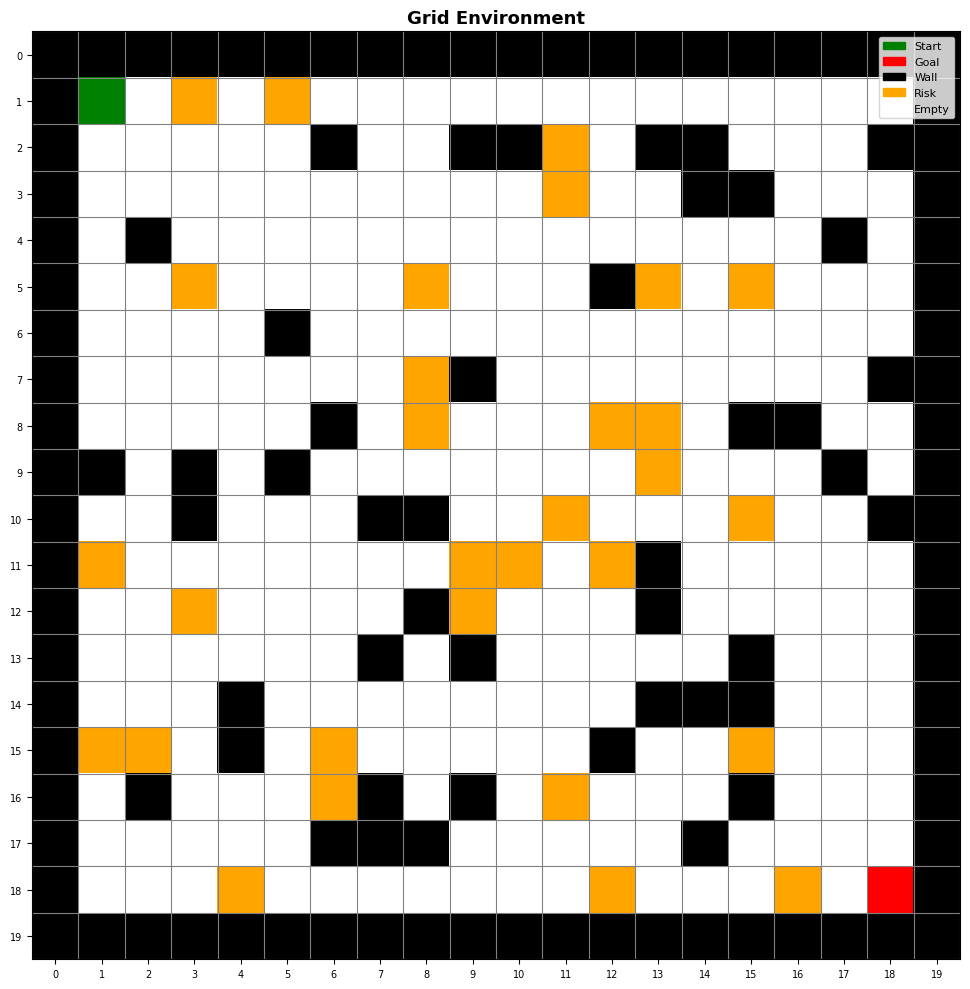

Start: (1, 1) | Goal: (18, 18)


In [2]:

Empty = 0
Wall  = 1
Start = 2
Goal  = 3
Risk  = 5

rows, cols = 20, 20

def create_environment(rows, cols, num_walls=45, num_risks=30, seed=42): # Fixed seed for reproducibility
    rng = np.random.default_rng(seed)
    env = np.zeros((rows, cols), dtype=int)
    env[0,:]  = Wall
    env[-1,:] = Wall
    env[:,0]  = Wall
    env[:,-1] = Wall

    placed = 0
    while placed < num_walls: # Place walls
        r = rng.integers(1, rows-1)
        c = rng.integers(1, cols-1)
        if env[r, c] == Empty and (r,c) not in [(1,1),(rows-2,cols-2)]:
            env[r, c] = Wall
            placed += 1

    placed = 0
    while placed < num_risks:
        r = rng.integers(1, rows-1)
        c = rng.integers(1, cols-1)
        if env[r, c] == Empty and (r,c) not in [(1,1),(rows-2,cols-2)]:
            env[r, c] = Risk
            placed += 1

    return env

def visualize_grid(env, path=None, title="Grid Environment", ax=None): #
    display = env.copy().astype(float)
    if path:
        for (r, c) in path:
            if env[r, c] not in (Start, Goal):
                display[r, c] = 4
        cmap   = ListedColormap(['white', 'black', 'green', 'red', 'royalblue', 'orange'])
        bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]
    else:
        cmap   = ListedColormap(['white', 'black', 'green', 'red', 'white', 'orange'])
        bounds = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5]

    norm       = BoundaryNorm(bounds, cmap.N)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(cols * 0.5, rows * 0.5)) # Adjust figure size based on grid dimensions

    ax.imshow(display, cmap=cmap, norm=norm)
    ax.set_aspect('equal') # Ensure square cells
    ax.set_xticks(np.arange(-.5, env.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-.5, env.shape[0], 1), minor=True)
    ax.grid(which='minor', color='gray', linewidth=0.8)
    ax.set_xticks(np.arange(0, cols, 1)) # Set major ticks at cell centers
    ax.set_yticks(np.arange(0, rows, 1))
    ax.set_xticklabels(np.arange(0, cols, 1), fontsize=7) # Set tick labels to show cell indices
    ax.set_yticklabels(np.arange(0, rows, 1), fontsize=7)
    ax.tick_params(which='minor', bottom=False, left=False) # Hide minor tick marks
    ax.set_title(title, fontsize=13, fontweight='bold')

    legend_items = [
        mpatches.Patch(color='green',  label='Start'),
        mpatches.Patch(color='red',    label='Goal'),
        mpatches.Patch(color='black',  label='Wall'),
        mpatches.Patch(color='orange', label='Risk'),
        mpatches.Patch(color='white',  label='Empty'),
    ]
    if path:
        legend_items.append(mpatches.Patch(color='royalblue', label='Path'))

    ax.legend(handles=legend_items, loc='upper right', fontsize=8)
    if standalone:
        plt.tight_layout()
        plt.show()

# --- Main ---
env         = create_environment(rows, cols)
start, goal = (1, 1), (rows-2, cols-2)
env[start]  = Start
env[goal]   = Goal

visualize_grid(env, title="Grid Environment")
print(f"Start: {start} | Goal: {goal}")

Graph Visualised

In [3]:
# Extract the dimensions of the grid environment
rows, cols = env.shape

# Initialize a 2D grid graph with the environment's dimensions
G = nx.grid_2d_graph(rows, cols)

# Identify all wall nodes and remove them
wall_nodes = [(r, c) for r in range(rows) for c in range(cols) if env[r, c] == Wall]
G.remove_nodes_from(wall_nodes)

# Assign edge weights based on the destination cell's type
# Normal cells cost 1, risky cells cost 3
CELL_COST = {Empty: 1, Start: 1, Goal: 1, Risk: 3}

for (u, v) in G.edges():
    dest_type = int(env[v])  # cost is determined by the cell you're entering
    G[u][v]['weight'] = CELL_COST.get(dest_type, 1)

print(f"Nodes : {G.number_of_nodes()}  (traversable cells: empty + risky + start + goal)")
print(f"Edges : {G.number_of_edges()}  (adjacent traversable-cell pairs)")
print(f"Risky cells: {sum(1 for r in range(rows) for c in range(cols) if env[r,c] == Risk)}")

Nodes : 279  (traversable cells: empty + risky + start + goal)
Edges : 451  (adjacent traversable-cell pairs)
Risky cells: 30


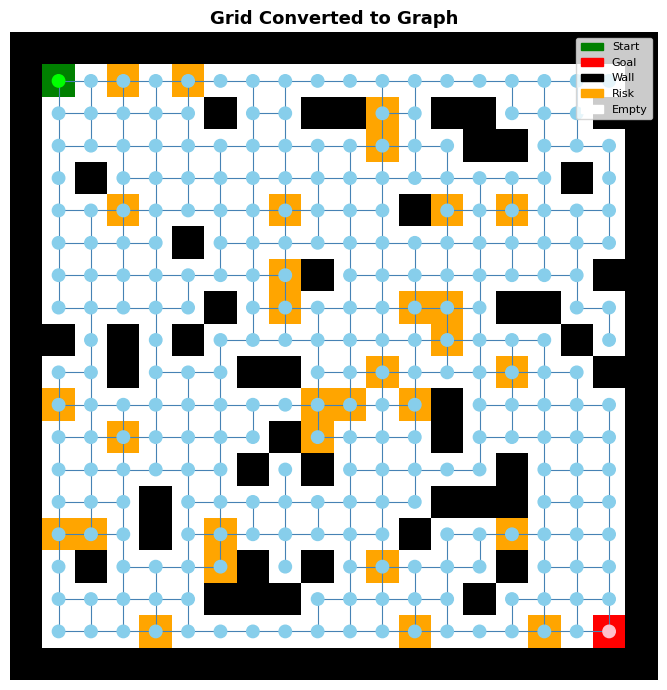

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))

# Draw the grid background using the shared visualize_grid function
visualize_grid(env, title="Grid Converted to Graph", ax=ax)

# Overlay the graph nodes and edges
pos = {(r, c): (c, r) for (r, c) in G.nodes()}
node_colors = ['lime' if n == start else 'pink' if n == goal else 'skyblue'
               for n in G.nodes()]

nx.draw(G, pos=pos, ax=ax,
        node_color=node_colors, node_size=80,
        edge_color='steelblue', width=0.8,
        with_labels=False)

plt.tight_layout()
plt.show()

Comparison

Algorithm  | Path Length | Total Cost | Runtime (ms) | Expanded Nodes
----------------------------------------------------------------------
BFS        |          34 |         42 |       1.4109 |            279
UCS        |          34 |         34 |       1.7698 |            279
Greedy     |          34 |         42 |       1.3349 |            261
A*         |          34 |         34 |       0.8012 |            196


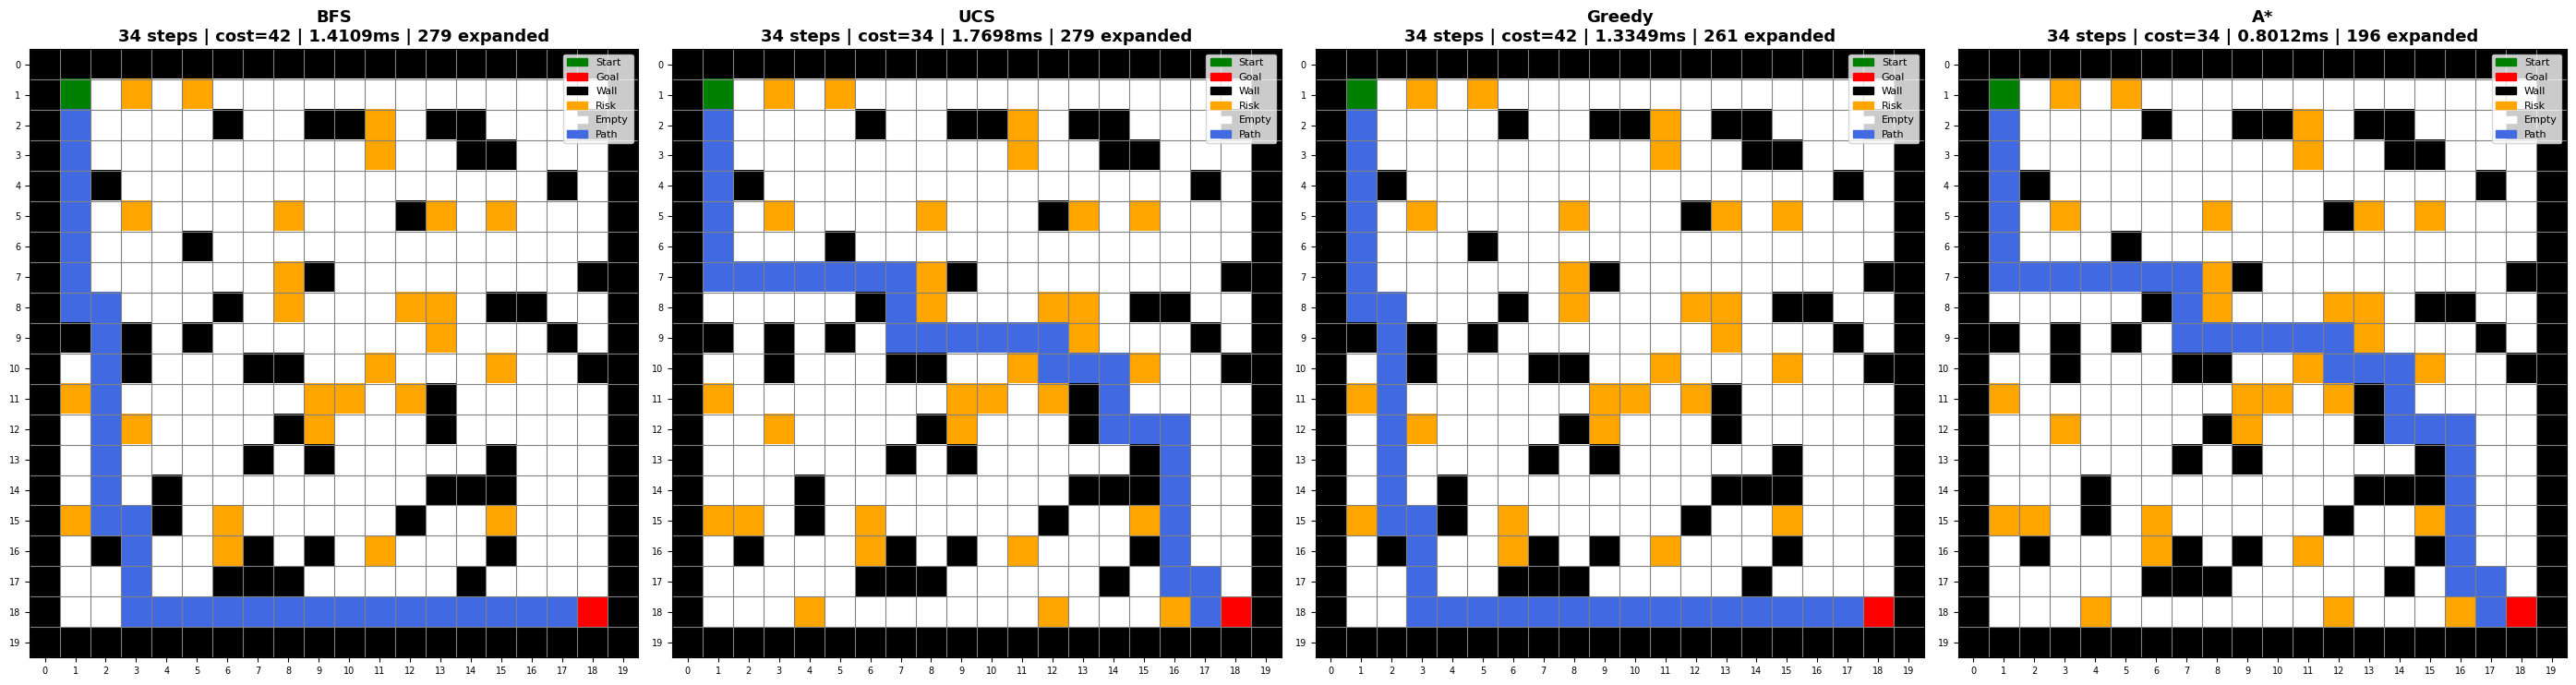

In [5]:
import heapq # For implementing the priority queue in A*
import time # For measuring runtime of algorithms

# ── Heuristic Functions ───────────────────────────────────────────────────────
def manhattan(a, b):
    """Manhattan distance heuristic for grid-based pathfinding."""
    # Assuming 'a' and 'b' are tuples or objects with 'r' (row) and 'c' (column) attributes.
    # For this problem, 'a' and 'b' are tuples (row, col).
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

# ── Custom A* with exact expanded-node counting ──────────────────────────────
def astar_with_count(G, source, target, heuristic=None, weight='weight'):
    """
    Runs A* and returns (path, expanded_node_count).
    - heuristic=None or lambda a,b: 0  →  UCS
    - weight=None                       →  Greedy (ignores edge costs)
    - both heuristic + weight           →  standard A*
    """
    if heuristic is None:
        heuristic = lambda a, b: 0

    counter = 0  # tie-breaker so heap never compares nodes directly
    # heap entry: (f_score, counter, node, g_score, parent)
    heap = [(0, counter, source, 0, None)]
    visited = set()
    came_from = {}   # node -> parent
    expand_count = 0

    while heap:
        f, _, node, g, parent = heapq.heappop(heap)
        if node in visited:
            continue
        visited.add(node)
        came_from[node] = parent
        expand_count += 1

        if node == target:
            # Reconstruct path
            path = []
            cur = node
            while cur is not None:
                path.append(cur)
                cur = came_from[cur]
            return list(reversed(path)), expand_count

        for neighbor in G.neighbors(node):
            if neighbor not in visited:
                edge_w = G[node][neighbor].get(weight, 1) if weight else 1
                new_g  = g + edge_w
                h      = heuristic(neighbor, target)
                counter += 1
                heapq.heappush(heap, (new_g + h, counter, neighbor, new_g, node))

    return None, expand_count  # no path found


# ── Run all four algorithms ───────────────────────────────────────────────────

# BFS — unweighted, finds shortest hop-count path
# ✅ Consistent BFS measurement
t0 = time.perf_counter()
bfs_path, bfs_expanded = astar_with_count(G, start, goal, heuristic=lambda a,b: 0, weight=None)
bfs_time = round((time.perf_counter() - t0) * 1000, 4)

# UCS — weighted, h=0, expands by true cost only
t0 = time.perf_counter()
ucs_path, ucs_expanded = astar_with_count(G, start, goal, heuristic=lambda a,b: 0, weight='weight')
ucs_time = round((time.perf_counter() - t0) * 1000, 4)

# Greedy — uses only heuristic, ignores edge costs
t0 = time.perf_counter()
greedy_path, greedy_expanded = astar_with_count(G, start, goal, heuristic=manhattan, weight=None)
greedy_time = round((time.perf_counter() - t0) * 1000, 4)

# A* — uses both cost and heuristic
t0 = time.perf_counter()
astar_path, astar_expanded = astar_with_count(G, start, goal, heuristic=manhattan, weight='weight')
astar_time = round((time.perf_counter() - t0) * 1000, 4)


# ── Compute total path costs (sum of edge weights) ───────────────────────────
def path_cost(G, path):
    return sum(G[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))

bfs_cost    = path_cost(G, bfs_path)
ucs_cost    = path_cost(G, ucs_path)
greedy_cost = path_cost(G, greedy_path)
astar_cost  = path_cost(G, astar_path)


# ── Print comparison table ────────────────────────────────────────────────────
print(f"{'Algorithm':<10} | {'Path Length':>11} | {'Total Cost':>10} | {'Runtime (ms)':>12} | {'Expanded Nodes':>14}")
print("-" * 70)
print(f"{'BFS':<10} | {len(bfs_path)-1:>11} | {bfs_cost:>10} | {bfs_time:>12} | {bfs_expanded:>14}")
print(f"{'UCS':<10} | {len(ucs_path)-1:>11} | {ucs_cost:>10} | {ucs_time:>12} | {ucs_expanded:>14}")
print(f"{'Greedy':<10} | {len(greedy_path)-1:>11} | {greedy_cost:>10} | {greedy_time:>12} | {greedy_expanded:>14}")
print(f"{'A*':<10} | {len(astar_path)-1:>11} | {astar_cost:>10} | {astar_time:>12} | {astar_expanded:>14}")


# ── Visualise all four paths ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(28, 7))

paths    = [bfs_path,     ucs_path,     greedy_path,     astar_path]
titles   = ["BFS",        "UCS",        "Greedy",        "A*"]
times    = [bfs_time,     ucs_time,     greedy_time,     astar_time]
expanded = [bfs_expanded, ucs_expanded, greedy_expanded, astar_expanded]
costs    = [bfs_cost,     ucs_cost,     greedy_cost,     astar_cost]

for ax, path, title, ms, exp, cost in zip(axes, paths, titles, times, expanded, costs):
    visualize_grid(
        env, path=path,
        title=f"{title}\n{len(path)-1} steps | cost={cost} | {ms}ms | {exp} expanded",
        ax=ax
    )

plt.tight_layout()
plt.show()

In [6]:
num_actions, grid_size = 4, 20
num_states = rows*cols
Q = np.zeros((rows*cols, 4))
Q

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [7]:
def step(state, action):
    row = state // grid_size
    col = state % grid_size

    new_row = row
    new_col = col
    if action == 0 and row > 0:       # Up
        new_row -= 1
    elif action == 1 and row < grid_size - 1:  # Down
        new_row += 1
    elif action == 2 and col > 0:     # Left
        new_col -= 1
    elif action == 3 and col < grid_size - 1:  # Right
        new_col += 1

    if env[new_row, new_col] == Wall:
        new_row, new_col = row, col

    next_state = new_row * grid_size + new_col
    goal_state = (rows-2)*grid_size +(cols-2)

    if next_state == goal_state:
        return next_state, 100, True

    elif env[new_row, new_col] == Risk:
        return next_state, -2, False #risk penalty
    else:
        return next_state, -1, False


In [8]:

alpha = 0.2
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.05
episodes = 500
max_steps = 400

In [9]:
start_state = 1*grid_size +1

for episode in range(episodes):
    state = start_state
    done = False
    steps = 0
    while not done:
        if steps >= max_steps:
            break

        steps += 1

        if random.random() < epsilon:
            action = random.randint(0, num_actions - 1)
        else:
            action = np.argmax(Q[state])

        next_state, reward, done = step(state, action)

        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )
        state = next_state
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
print("training complete")

training complete


In [10]:
Q

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [11]:

state = start_state
path = [state]
done = False

while not done and len(path) < max_steps:
    action = np.argmax(Q[state]) # Choose the action with the highest Q-value for the current state
    state, _, done = step(state, action) # Take the action and observe the next state and reward
    path.append(state)

print("Agent path:", path)


Agent path: [21, 41, 42, 62, 63, 64, 65, 66, 67, 68, 88, 89, 109, 129, 130, 150, 170, 171, 191, 211, 212, 213, 214, 234, 254, 255, 256, 257, 277, 297, 317, 337, 357, 377, 378]


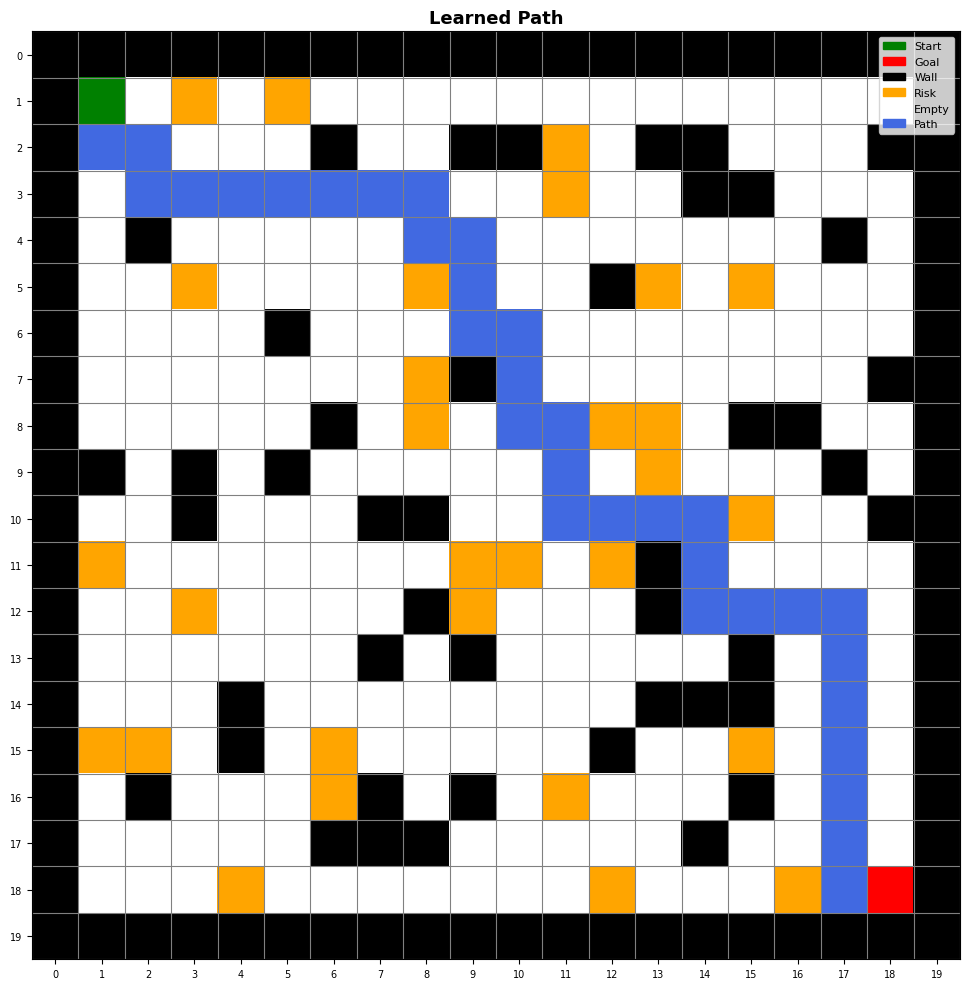

Path length: 35 steps
Risk cells hit: 1


In [12]:
path_coords = [(s // grid_size, s % grid_size) for s in path] # Convert state indices to (row, col) coordinates
visualize_grid(env, path=path_coords, title="Learned Path") # Visualize the grid with the learned path
print(f"Path length: {len(path)} steps") # Print the length of the path
print(f"Risk cells hit: {sum(env[r,c] == Risk for r,c in path_coords)}") # Print the number of risk cells hit along the path

Training complete


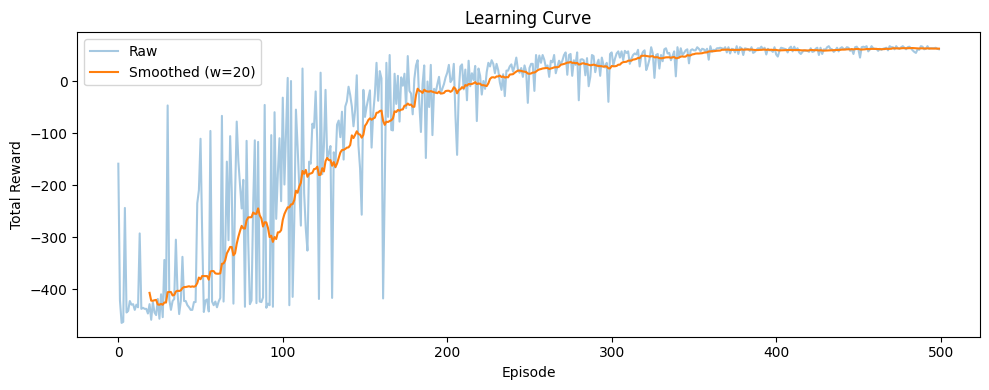

In [13]:
start_state = 1 * grid_size + 1 # Reset start state for training loop
rewards_per_episode = []
Q = np.zeros((rows * cols, 4)) # Reset Q-table before training
epsilon = 1.0 # Reset epsilon before training

for episode in range(episodes):
    state = start_state
    done = False
    total_reward = 0
    steps = 0

    while not done and steps < max_steps:
        if random.random() < epsilon:
            action = random.randint(0, num_actions - 1)
        else:
            action = np.argmax(Q[state])

        next_state, reward, done = step(state, action)

        Q[state, action] += alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )
        state = next_state
        total_reward += reward
        steps += 1

    rewards_per_episode.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training complete")

# Learning curve
plt.figure(figsize=(10, 4))
plt.plot(rewards_per_episode, alpha=0.4, label='Raw')
# Smoothed line to see the trend clearly
window = 20 # Moving average window size
smoothed = np.convolve(rewards_per_episode, np.ones(window)/window, mode='valid') # Compute moving average for smoothing
plt.plot(range(window-1, len(rewards_per_episode)), smoothed, label=f'Smoothed (w={window})')
plt.title("Learning Curve")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# =====================================================================
#  🎮 FORTNITE AI DASHBOARD — MATCHED TO YOUR GRID ENVIRONMENT
#
#  Grid matches create_environment(rows=20, cols=20, seed=42) exactly:
#   - 45 walls placed with seeded RNG
#   - 30 risk zones (orange, cost=5) placed with seeded RNG
#   - Start (1,1)  →  Goal (18,18)
#   - Border cells are all walls
#
#  Risk cells are traversable but cost 5× more — algorithms account
#  for this in their cost functions.
#
#  INSTRUCTIONS:
#  1. Copy this ENTIRE file
#  2. Paste into a single Google Colab cell (after your env cell)
#  3. Run the cell (Shift+Enter)
# =====================================================================

from IPython.display import HTML, display
import json, numpy as np

# ── Replicate your exact grid so JS gets the same layout ─────────────
Empty = 0; Wall = 1; Start = 2; Goal = 3; Risk = 5

def create_environment(rows, cols, num_walls=45, num_risks=30, seed=42):
    rng = np.random.default_rng(seed)
    env = np.zeros((rows, cols), dtype=int)
    env[0,:] = Wall; env[-1,:] = Wall
    env[:,0] = Wall; env[:,-1] = Wall
    placed = 0
    while placed < num_walls:
        r = rng.integers(1, rows-1); c = rng.integers(1, cols-1)
        if env[r,c] == Empty and (r,c) not in [(1,1),(rows-2,cols-2)]:
            env[r,c] = Wall; placed += 1
    placed = 0
    while placed < num_risks:
        r = rng.integers(1, rows-1); c = rng.integers(1, cols-1)
        if env[r,c] == Empty and (r,c) not in [(1,1),(rows-2,cols-2)]:
            env[r,c] = Risk; placed += 1
    return env

rows, cols = 20, 20
env = create_environment(rows, cols)
start_pos, goal_pos = (1, 1), (rows-2, cols-2)
env[start_pos] = Start
env[goal_pos]  = Goal

# Export grid as plain integers for JS (0=empty,1=wall,2=start,3=goal,5=risk)
grid_list = env.tolist()

html_code = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1.0"/>
<title>Fortnite AI Dashboard</title>
<script src="https://cdn.jsdelivr.net/npm/@tailwindcss/browser@4"></script>
<style>
  @import url('https://fonts.googleapis.com/css2?family=Russo+One&family=Orbitron:wght@500;700;900&display=swap');
  :root{--fn-blue:#00f0ff;--fn-purple:#b14eff;--fn-yellow:#ffe94a;--fn-pink:#ff2e93;--fn-green:#2ee86b;--fn-orange:#ff8a1e;}
  *{box-sizing:border-box;}
  html,body{margin:0;padding:0;min-height:100vh;}
  body{
    font-family:'Russo One','Orbitron',system-ui,sans-serif;color:#fff;
    background:
      radial-gradient(ellipse at 20% 10%,rgba(177,78,255,.35),transparent 55%),
      radial-gradient(ellipse at 80% 90%,rgba(0,240,255,.30),transparent 55%),
      radial-gradient(ellipse at 50% 50%,rgba(255,46,147,.15),transparent 60%),
      linear-gradient(180deg,#0b0324 0%,#1a0640 40%,#2a0a5c 100%);
    background-attachment:fixed;overflow-x:hidden;
  }
  .bg-layer{position:fixed;inset:0;z-index:-2;background-image:linear-gradient(rgba(11,3,36,.45),rgba(11,3,36,.60)),url('https://i.redd.it/ga1z47umgh671.png');background-size:cover;background-position:center;filter:saturate(1.1) contrast(1.05);}
  .bg-grid{position:fixed;inset:0;z-index:-1;pointer-events:none;background-image:linear-gradient(rgba(0,240,255,.06) 1px,transparent 1px),linear-gradient(90deg,rgba(0,240,255,.06) 1px,transparent 1px);background-size:60px 60px;mask-image:radial-gradient(ellipse at center,#000 30%,transparent 80%);}
  .fn-title{font-family:'Russo One',Impact,sans-serif;font-weight:900;letter-spacing:.02em;text-transform:uppercase;-webkit-text-stroke:1px rgba(0,0,0,.4);paint-order:stroke fill;}
  .glow-blue{text-shadow:0 0 10px rgba(0,240,255,.9),0 0 25px rgba(0,240,255,.5);}
  .glow-purple{text-shadow:0 0 10px rgba(177,78,255,.9),0 0 25px rgba(177,78,255,.5);}
  .glow-pink{text-shadow:0 0 10px rgba(255,46,147,.9),0 0 25px rgba(255,46,147,.5);}
  .glow-yellow{text-shadow:0 0 10px rgba(255,233,74,.9),0 0 25px rgba(255,233,74,.5);}
  .panel{background:linear-gradient(180deg,rgba(20,8,60,.55),rgba(10,3,40,.55));backdrop-filter:blur(10px);border:2px solid rgba(0,240,255,.35);box-shadow:0 0 0 1px rgba(255,255,255,.04) inset,0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(0,240,255,.15);clip-path:polygon(0 12px,12px 0,calc(100% - 24px) 0,100% 24px,100% calc(100% - 12px),calc(100% - 12px) 100%,24px 100%,0 calc(100% - 24px));}
  .panel-pink{border-color:rgba(255,46,147,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(255,46,147,.2);}
  .panel-purple{border-color:rgba(177,78,255,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(177,78,255,.25);}
  .panel-yellow{border-color:rgba(255,233,74,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(255,233,74,.2);}
  .panel-green{border-color:rgba(46,232,107,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(46,232,107,.25);}
  .rarity{display:inline-block;padding:3px 10px;font-size:11px;letter-spacing:.12em;text-transform:uppercase;border-radius:3px;font-weight:700;}
  .r-legendary{background:linear-gradient(90deg,#ff8a1e,#ffb347);color:#2a0a00;}
  .r-epic{background:linear-gradient(90deg,#b14eff,#d88cff);color:#1a0030;}
  .r-rare{background:linear-gradient(90deg,#00a8ff,#4dc8ff);color:#001a2a;}
  .r-uncommon{background:linear-gradient(90deg,#2ee86b,#7bf2a0);color:#002a0f;}
  .algo-btn{position:relative;padding:10px 18px;background:linear-gradient(180deg,rgba(255,255,255,.08),rgba(255,255,255,.02));border:1px solid rgba(0,240,255,.5);color:#e7fbff;font-family:'Russo One',sans-serif;letter-spacing:.12em;text-transform:uppercase;font-size:12px;cursor:pointer;clip-path:polygon(8px 0,100% 0,100% calc(100% - 8px),calc(100% - 8px) 100%,0 100%,0 8px);transition:all .2s;}
  .algo-btn:hover{background:rgba(0,240,255,.15);}
  .algo-btn.active{background:linear-gradient(180deg,#00f0ff,#0080ff);color:#001a2a;border-color:#fff;box-shadow:0 0 20px rgba(0,240,255,.7);}
  .skin-card{position:relative;background:linear-gradient(180deg,rgba(177,78,255,.12),rgba(0,240,255,.08));border:1px solid rgba(255,255,255,.15);border-radius:6px;padding:14px 10px 16px;text-align:center;overflow:hidden;transition:transform .25s;}
  .skin-card:hover{transform:translateY(-4px);}
  .skin-card img{width:100%;height:220px;object-fit:contain;filter:drop-shadow(0 8px 14px rgba(0,0,0,.6));}
  .skin-card::before{content:"";position:absolute;inset:0;background:radial-gradient(circle at 50% 40%,rgba(255,255,255,.15),transparent 60%);pointer-events:none;}
  .stat-row{display:flex;align-items:center;gap:10px;margin:6px 0;font-size:12px;}
  .stat-label{width:120px;color:#c8b9ff;letter-spacing:.08em;text-transform:uppercase;font-size:11px;}
  .stat-bar{flex:1;height:10px;background:rgba(255,255,255,.08);border-radius:2px;overflow:hidden;}
  .stat-fill{height:100%;border-radius:2px;transition:width 1s cubic-bezier(.2,.8,.2,1);}
  .logo-wrap{display:flex;justify-content:center;align-items:center;padding:30px 0 10px;}
  .logo-wrap img{width:min(560px,82vw);filter:drop-shadow(0 0 30px rgba(0,240,255,.75)) drop-shadow(0 0 60px rgba(177,78,255,.5));animation:pulseLogo 3s ease-in-out infinite;}
  @keyframes pulseLogo{0%,100%{filter:drop-shadow(0 0 30px rgba(0,240,255,.75)) drop-shadow(0 0 60px rgba(177,78,255,.5));}50%{filter:drop-shadow(0 0 45px rgba(255,46,147,.8)) drop-shadow(0 0 70px rgba(0,240,255,.6));}}
  .hud{display:flex;justify-content:space-between;align-items:center;padding:8px 16px;background:linear-gradient(90deg,rgba(0,0,0,.55),rgba(0,0,0,.25),rgba(0,0,0,.55));border-bottom:1px solid rgba(0,240,255,.25);font-size:12px;letter-spacing:.15em;}
  .grid-view{display:grid;gap:1px;background:rgba(0,0,0,.5);padding:4px;border-radius:6px;border:1px solid rgba(0,240,255,.25);}
  /* Base cell */
  .cell{aspect-ratio:1/1;background:rgba(255,255,255,.04);border-radius:1px;font-size:7px;display:flex;align-items:center;justify-content:center;color:rgba(255,255,255,.3);transition:background .12s;}
  /* Wall — storm cloud purple */
  .cell.wall{background:linear-gradient(135deg,#2d1b4e,#4a1a5e);box-shadow:inset 0 0 6px rgba(177,78,255,.6);animation:stormGlow 2s ease-in-out infinite;}
  @keyframes stormGlow{0%,100%{box-shadow:inset 0 0 6px rgba(177,78,255,.6);}50%{box-shadow:inset 0 0 10px rgba(177,78,255,.85);}}
  /* Risk — orange glow, traversable but costly */
  .cell.risk{background:linear-gradient(135deg,rgba(255,138,30,.55),rgba(255,80,0,.4));box-shadow:inset 0 0 5px rgba(255,138,30,.5);}
  /* Start / Goal locked with !important */
  .cell.start{background:linear-gradient(135deg,#2ee86b,#00a85a) !important;color:#001a0a !important;font-weight:700;box-shadow:0 0 10px rgba(46,232,107,.8) !important;}
  .cell.goal{background:linear-gradient(135deg,#ff2e93,#ff8a1e) !important;color:#fff !important;font-weight:700;box-shadow:0 0 10px rgba(255,46,147,.8) !important;}
  /* Exploration clouds */
  .cell.visited-rl{background:linear-gradient(135deg,rgba(255,215,0,.55),rgba(255,46,147,.45));box-shadow:inset 0 0 4px rgba(255,215,0,.4);}
  .cell.visited-ucs{background:linear-gradient(135deg,rgba(0,240,255,.55),rgba(0,128,255,.4));box-shadow:inset 0 0 4px rgba(0,240,255,.5);}
  .cell.visited-astar{background:linear-gradient(135deg,rgba(46,232,107,.55),rgba(0,240,255,.4));box-shadow:inset 0 0 4px rgba(46,232,107,.5);}
  .cell.visited-greedy{background:linear-gradient(135deg,rgba(255,46,147,.6),rgba(177,78,255,.5));box-shadow:inset 0 0 4px rgba(255,46,147,.5);}
  /* Path — gold, beats everything */
  .cell.path{background:linear-gradient(135deg,#ffe94a,#ff8a1e) !important;color:#2a0a00 !important;font-weight:800 !important;box-shadow:0 0 16px rgba(255,233,74,1),0 0 28px rgba(255,138,30,.8) !important;animation:pathPulse 1s ease-in-out infinite !important;position:relative;z-index:2;}
  @keyframes pathPulse{0%,100%{box-shadow:0 0 12px rgba(255,233,74,1),0 0 20px rgba(255,138,30,.6);}50%{box-shadow:0 0 22px rgba(255,233,74,1),0 0 34px rgba(255,138,30,.9);}}
  ::-webkit-scrollbar{width:10px;}
  ::-webkit-scrollbar-track{background:rgba(0,0,0,.3);}
  ::-webkit-scrollbar-thumb{background:linear-gradient(#00f0ff,#b14eff);border-radius:10px;}
  .chip{display:inline-flex;align-items:center;gap:6px;padding:4px 10px;border-radius:999px;background:rgba(0,0,0,.4);border:1px solid rgba(255,255,255,.15);font-size:11px;letter-spacing:.1em;}
</style>
</head>
<body>
<div class="bg-layer"></div>
<div class="bg-grid"></div>

<div class="hud">
  <div class="flex items-center gap-3">
    <span class="chip" style="border-color:#2ee86b;color:#9fffc1">● LIVE</span>
    <span class="chip">MATCH #2077</span>
    <span class="chip">SQUAD</span>
  </div>
  <div class="flex items-center gap-3">
    <span class="chip">🌩 STORM: CLOSING</span>
    <span class="chip">⚡ PLAYERS: 42 / 100</span>
    <span class="chip" style="border-color:#ffe94a;color:#ffe94a">🏆 VICTORY ROYALE MODE</span>
  </div>
</div>

<div class="logo-wrap">
  <img src="https://pngimg.com/uploads/fortnite/fortnite_PNG25.png" alt="Fortnite Logo"/>
</div>

<div class="text-center -mt-2 mb-6 px-4">
  <h1 class="fn-title text-3xl md:text-5xl glow-yellow">AI Battle Royale — Pathfinding Showdown</h1>
  <p class="mt-2 text-sm md:text-base text-cyan-200/90 tracking-widest uppercase">
    Reinforcement Learning <span class="text-pink-400">VS</span> Uniform Cost Search
    <span class="text-pink-400">VS</span> A* <span class="text-pink-400">VS</span> Greedy Search
  </p>
</div>

<main class="max-w-7xl mx-auto px-4 pb-20">

  <!-- SQUAD SKINS -->
  <section class="mb-10">
    <div class="flex items-center justify-between mb-4">
      <h2 class="fn-title text-2xl md:text-3xl glow-blue">The Squad — Choose Your Agent</h2>
      <span class="rarity r-legendary">LEGENDARY DROP</span>
    </div>
    <div class="grid grid-cols-1 md:grid-cols-3 gap-6">
      <div class="skin-card">
        <div class="flex items-center justify-between mb-1 px-1">
          <span class="fn-title text-xl text-green-300">FISHSTICK</span>
          <span class="rarity r-rare">RARE</span>
        </div>
        <p class="text-xs text-cyan-200/80 mb-2 italic">"Keep far away from Maki Master."</p>
        <img src="https://fortnite-api.com/images/cosmetics/br/cid_315_athena_commando_m_teriyakifish/full.png" onerror="this.onerror=null;this.src='https://fortnite-api.com/images/cosmetics/br/cid_315_athena_commando_m_teriyakifish/icon.png'" alt="Fishstick skin"/>
        <div class="mt-2 text-left px-2">
          <div class="stat-row"><span class="stat-label">Assigned</span><span class="text-green-300 font-bold">A* SEARCH</span></div>
          <div class="stat-row"><span class="stat-label">Accuracy</span><div class="stat-bar"><div class="stat-fill" style="width:95%;background:linear-gradient(90deg,#2ee86b,#00f0ff)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Optimality</span><div class="stat-bar"><div class="stat-fill" style="width:100%;background:linear-gradient(90deg,#2ee86b,#00f0ff)"></div></div></div>
        </div>
      </div>
      <div class="skin-card" style="background:linear-gradient(180deg,rgba(255,46,147,.15),rgba(255,215,0,.10))">
        <div class="flex items-center justify-between mb-1 px-1">
          <span class="fn-title text-xl text-yellow-300">WONDER WOMAN</span>
          <span class="rarity r-legendary">DC SERIES</span>
        </div>
        <p class="text-xs text-yellow-200/90 mb-2 italic">"Amazonian warrior and daughter of Zeus."</p>
        <img src="https://fortnite-api.com/images/cosmetics/br/cid_a_187_athena_commando_f_monarch/full.png" onerror="this.onerror=null;this.src='https://fortnite-api.com/images/cosmetics/br/cid_a_187_athena_commando_f_monarch/icon.png'" alt="Wonder Woman skin"/>
        <div class="mt-2 text-left px-2">
          <div class="stat-row"><span class="stat-label">Assigned</span><span class="text-yellow-300 font-bold">RL (Q-LEARN)</span></div>
          <div class="stat-row"><span class="stat-label">Learning</span><div class="stat-bar"><div class="stat-fill" style="width:98%;background:linear-gradient(90deg,#ff2e93,#ffd700)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Adaptation</span><div class="stat-bar"><div class="stat-fill" style="width:92%;background:linear-gradient(90deg,#ff2e93,#ffd700)"></div></div></div>
        </div>
      </div>
      <div class="skin-card" style="background:linear-gradient(180deg,rgba(0,240,255,.12),rgba(177,78,255,.10))">
        <div class="flex items-center justify-between mb-1 px-1">
          <span class="fn-title text-xl text-cyan-300">CHAMPION SPARKPLUG</span>
          <span class="rarity r-epic">EPIC</span>
        </div>
        <p class="text-xs text-cyan-200/80 mb-2 italic">"Scrap your way to the top."</p>
        <img src="https://fortnite-api.com/images/cosmetics/br/character_garbagefncs/full.png" onerror="this.onerror=null;this.src='https://fortnite-api.com/images/cosmetics/br/character_garbagefncs/icon.png'" alt="Champion Sparkplug skin"/>
        <div class="mt-2 text-left px-2">
          <div class="stat-row"><span class="stat-label">Assigned</span><span class="text-cyan-300 font-bold">UCS + GREEDY</span></div>
          <div class="stat-row"><span class="stat-label">Speed</span><div class="stat-bar"><div class="stat-fill" style="width:88%;background:linear-gradient(90deg,#00f0ff,#b14eff)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Efficiency</span><div class="stat-bar"><div class="stat-fill" style="width:76%;background:linear-gradient(90deg,#00f0ff,#b14eff)"></div></div></div>
        </div>
      </div>
    </div>
  </section>

  <!-- CONTROLS -->
  <section class="panel p-4 md:p-5 mb-8">
    <div class="flex flex-wrap items-center gap-3 justify-between">
      <div class="flex flex-wrap gap-2">
        <button class="algo-btn active" data-algo="rl">🧠 Reinforcement Learning</button>
        <button class="algo-btn" data-algo="ucs">🎯 Uniform Cost Search</button>
        <button class="algo-btn" data-algo="astar">⭐ A* Search</button>
        <button class="algo-btn" data-algo="greedy">🔥 Greedy Search</button>
      </div>
      <div class="flex flex-wrap gap-2">
        <button id="runBtn" class="algo-btn active" style="background:linear-gradient(180deg,#ff2e93,#b14eff);color:#fff">▶ RUN MATCH</button>
        <button id="resetBtn" class="algo-btn">↺ RESET LOBBY</button>
        <button id="stepBtn" class="algo-btn">⏭ STEP</button>
      </div>
    </div>
    <div class="mt-3 text-xs text-cyan-200/70 tracking-wider">
      CURRENT LOADOUT: <span id="currentAlgo" class="text-pink-300 font-bold">REINFORCEMENT LEARNING (Q-LEARNING)</span> —
      GRID <span id="gridSizeLabel">20×20</span> · RISK COST: 5 · HEURISTIC: MANHATTAN
    </div>
  </section>

  <!-- MAP + STATS -->
  <section class="grid grid-cols-1 lg:grid-cols-3 gap-6">
    <div class="lg:col-span-2 panel p-5">
      <div class="flex items-center justify-between mb-3">
        <h3 class="fn-title text-xl md:text-2xl glow-purple">BATTLE MAP — seed=42 · cost-aware</h3>
        <span class="chip" style="border-color:#ffe94a;color:#ffe94a">⚡ LIVE</span>
      </div>
      <div id="grid" class="grid-view"></div>
      <div class="grid grid-cols-3 md:grid-cols-6 gap-2 mt-4 text-xs">
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:#2ee86b;border-radius:2px;display:inline-block;flex-shrink:0"></span> Start</div>
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:#ff2e93;border-radius:2px;display:inline-block;flex-shrink:0"></span> Goal</div>
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:#3a1f5c;border-radius:2px;display:inline-block;flex-shrink:0"></span> Wall</div>
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:#ff8a1e;border-radius:2px;display:inline-block;flex-shrink:0"></span> Risk (×5)</div>
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:#ffe94a;border-radius:2px;display:inline-block;flex-shrink:0"></span> Path</div>
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:rgba(255,255,255,.08);border:1px solid rgba(255,255,255,.2);border-radius:2px;display:inline-block;flex-shrink:0"></span> Empty</div>
      </div>
    </div>

    <div class="space-y-6">
      <div class="panel panel-pink p-5">
        <h3 class="fn-title text-xl glow-pink">MATCH STATS</h3>
        <div class="grid grid-cols-2 gap-3 mt-3">
          <div class="text-center"><div class="text-3xl font-black text-pink-300" id="statNodes">0</div><div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Nodes Explored</div></div>
          <div class="text-center"><div class="text-3xl font-black text-cyan-300" id="statPath">0</div><div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Path Length</div></div>
          <div class="text-center"><div class="text-3xl font-black text-yellow-300" id="statCost">0</div><div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Total Cost</div></div>
          <div class="text-center"><div class="text-3xl font-black text-green-300" id="statTime">0<span class="text-sm">ms</span></div><div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Runtime</div></div>
        </div>
      </div>
      <div class="panel panel-purple p-5">
        <h3 class="fn-title text-xl glow-purple">XP GAINED</h3>
        <div class="mt-3 space-y-2 text-xs">
          <div class="stat-row"><span class="stat-label">Completeness</span><div class="stat-bar"><div class="stat-fill" id="barComplete" style="width:100%;background:linear-gradient(90deg,#2ee86b,#00f0ff)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Optimality</span><div class="stat-bar"><div class="stat-fill" id="barOptimal" style="width:75%;background:linear-gradient(90deg,#ffe94a,#ff8a1e)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Time Efficiency</span><div class="stat-bar"><div class="stat-fill" id="barTime" style="width:60%;background:linear-gradient(90deg,#ff2e93,#b14eff)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Space Efficiency</span><div class="stat-bar"><div class="stat-fill" id="barSpace" style="width:55%;background:linear-gradient(90deg,#00f0ff,#b14eff)"></div></div></div>
        </div>
      </div>
    </div>
  </section>

  <!-- LEADERBOARD -->
  <section class="panel panel-yellow p-5 mt-8">
    <h3 class="fn-title text-2xl glow-yellow">LEADERBOARD — ALGORITHM COMPARISON</h3>
    <div class="overflow-x-auto mt-4">
      <table class="w-full text-sm">
        <thead>
          <tr class="text-left text-cyan-200/80 uppercase text-xs tracking-widest border-b border-cyan-500/30">
            <th class="py-2 pr-3">#</th><th class="py-2 pr-3">Agent</th><th class="py-2 pr-3">Algorithm</th>
            <th class="py-2 pr-3">Complete?</th><th class="py-2 pr-3">Optimal?</th>
            <th class="py-2 pr-3">Time</th><th class="py-2 pr-3">Space</th>
            <th class="py-2 pr-3">Nodes</th><th class="py-2 pr-3">Cost</th><th class="py-2 pr-3">Rank</th>
          </tr>
        </thead>
        <tbody class="text-white/90">
          <tr class="border-b border-white/5 hover:bg-white/5">
            <td class="py-3 pr-3 text-yellow-300 font-black">1</td>
            <td class="py-3 pr-3"><span class="text-green-300 font-bold">FISHSTICK</span></td>
            <td class="py-3 pr-3">A*</td>
            <td class="py-3 pr-3 text-green-300">✓ Yes</td><td class="py-3 pr-3 text-green-300">✓ Yes*</td>
            <td class="py-3 pr-3">O(b^d)</td><td class="py-3 pr-3">O(b^d)</td>
            <td class="py-3 pr-3" id="lb-astar-nodes">—</td><td class="py-3 pr-3" id="lb-astar-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-legendary">#1</span></td>
          </tr>
          <tr class="border-b border-white/5 hover:bg-white/5">
            <td class="py-3 pr-3 text-gray-300 font-black">2</td>
            <td class="py-3 pr-3"><span class="text-yellow-300 font-bold">WONDER WOMAN</span></td>
            <td class="py-3 pr-3">RL (Q-Learn)</td>
            <td class="py-3 pr-3 text-yellow-300">~ After train</td><td class="py-3 pr-3 text-yellow-300">~ Convergence</td>
            <td class="py-3 pr-3">O(episodes)</td><td class="py-3 pr-3">O(|S|·|A|)</td>
            <td class="py-3 pr-3" id="lb-rl-nodes">—</td><td class="py-3 pr-3" id="lb-rl-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-epic">#2</span></td>
          </tr>
          <tr class="border-b border-white/5 hover:bg-white/5">
            <td class="py-3 pr-3 text-gray-300 font-black">3</td>
            <td class="py-3 pr-3"><span class="text-cyan-300 font-bold">CHAMP. SPARKPLUG</span></td>
            <td class="py-3 pr-3">UCS</td>
            <td class="py-3 pr-3 text-green-300">✓ Yes</td><td class="py-3 pr-3 text-green-300">✓ Yes</td>
            <td class="py-3 pr-3">O(b^(1+⌊C*/ε⌋))</td><td class="py-3 pr-3">O(same)</td>
            <td class="py-3 pr-3" id="lb-ucs-nodes">—</td><td class="py-3 pr-3" id="lb-ucs-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-rare">#3</span></td>
          </tr>
          <tr class="hover:bg-white/5">
            <td class="py-3 pr-3 text-gray-300 font-black">4</td>
            <td class="py-3 pr-3"><span class="text-cyan-300 font-bold">CHAMP. SPARKPLUG</span></td>
            <td class="py-3 pr-3">Greedy BFS</td>
            <td class="py-3 pr-3 text-red-300">✗ No</td><td class="py-3 pr-3 text-red-300">✗ No</td>
            <td class="py-3 pr-3">O(b^m)</td><td class="py-3 pr-3">O(b^m)</td>
            <td class="py-3 pr-3" id="lb-greedy-nodes">—</td><td class="py-3 pr-3" id="lb-greedy-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-uncommon">#4</span></td>
          </tr>
        </tbody>
      </table>
    </div>
    <p class="text-[11px] text-cyan-200/60 mt-3 italic">*A* optimal when h(n) admissible & consistent. Risk cells cost 5 — all cost-aware algos avoid them when cheaper routes exist.</p>
  </section>

  <!-- ALGO CARDS -->
  <section class="grid grid-cols-1 md:grid-cols-2 gap-6 mt-8">
    <div class="panel p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#ff2e93,#ffd700)">🧠</div>
        <h3 class="fn-title text-xl glow-pink">REINFORCEMENT LEARNING</h3>
        <span class="rarity r-legendary ml-auto">WONDER WOMAN</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Learns through trial and error with <span class="text-yellow-300">risk-aware rewards</span> — stepping on orange risk zones incurs a −5 penalty. Builds a Q-table over 600 episodes, then exploits learned policy.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-pink-500/30 text-pink-200">Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') − Q(s,a)]</div>
    </div>
    <div class="panel panel-green p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#2ee86b,#00a85a)">⭐</div>
        <h3 class="fn-title text-xl glow-blue">A* SEARCH</h3>
        <span class="rarity r-legendary ml-auto">FISHSTICK</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Uses actual edge cost (1 for empty, 5 for risk) + Manhattan heuristic. Guaranteed to find the lowest-cost path through the storm.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-green-500/30 text-green-200">f(n) = g(n) + h(n) &nbsp;// cost(empty)=1, cost(risk)=5</div>
    </div>
    <div class="panel p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#00f0ff,#0080ff)">🎯</div>
        <h3 class="fn-title text-xl glow-blue">UNIFORM COST SEARCH</h3>
        <span class="rarity r-rare ml-auto">CHAMP. SPARKPLUG</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Expands lowest-cost node first using a priority queue. Optimal — always finds the cheapest route even through risk terrain. No heuristic.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-cyan-500/30 text-cyan-200">expand argmin g(n) · cost ∈ {1, 5}</div>
    </div>
    <div class="panel panel-yellow p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#ffe94a,#ff8a1e)">🔥</div>
        <h3 class="fn-title text-xl glow-yellow">GREEDY BEST-FIRST</h3>
        <span class="rarity r-uncommon ml-auto">CHAMP. SPARKPLUG</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Rushes toward goal using only Manhattan distance. Ignores risk costs — may charge straight through orange zones. Fast but suboptimal.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-yellow-500/30 text-yellow-200">expand argmin h(n) &nbsp;// cost-blind, risk-prone</div>
    </div>
  </section>

  <footer class="text-center mt-12 text-xs text-cyan-200/60 tracking-widest">
    ⚡ FORTNITE × AI DASHBOARD · SEED=42 · RISK-AWARE PATHFINDING ⚡
  </footer>
</main>

<script>
// ══════════════════════════════════════════════════════════════════════
//  CONSTANTS matching your Python environment
// ══════════════════════════════════════════════════════════════════════
const EMPTY=0,WALL=1,START=2,GOAL=3,RISK=5;
const RISK_COST=5, EMPTY_COST=1;

let ROWS=20,COLS=20;
let currentAlgo='rl';
let running=false;

// Grid injected from Python below
let grid=__GRID_JSON__;

const start={r:1,c:1}, goal={r:18,c:18};

const algoDesc={
  rl:'REINFORCEMENT LEARNING (Q-LEARNING)',
  ucs:'UNIFORM COST SEARCH (DIJKSTRA)',
  astar:'A* SEARCH (FISHSTICK MODE)',
  greedy:'GREEDY BEST-FIRST SEARCH'
};

// ─── RENDER ───────────────────────────────────────────────────────────
const gridEl=document.getElementById('grid');

function renderGrid(){
  gridEl.style.gridTemplateColumns=`repeat(${COLS},1fr)`;
  gridEl.innerHTML='';
  for(let r=0;r<ROWS;r++) for(let c=0;c<COLS;c++){
    const v=grid[r][c];
    const el=document.createElement('div');
    el.className='cell'; el.id=`c-${r}-${c}`;
    if(v===START){el.classList.add('start');el.textContent='S';}
    else if(v===GOAL){el.classList.add('goal');el.textContent='G';}
    else if(v===WALL) el.classList.add('wall');
    else if(v===RISK) el.classList.add('risk');
    gridEl.appendChild(el);
  }
}

function clearOverlay(){
  document.querySelectorAll('.cell').forEach(c=>
    c.classList.remove('visited-rl','visited-ucs','visited-astar','visited-greedy','path'));
}

// ─── COST FUNCTION ────────────────────────────────────────────────────
function moveCost(r,c){
  const v=grid[r][c];
  if(v===WALL) return Infinity;
  if(v===RISK)  return RISK_COST;
  return EMPTY_COST;
}

function neighbors(r,c){
  return [[1,0],[-1,0],[0,1],[0,-1]]
    .map(([dr,dc])=>({r:r+dr,c:c+dc}))
    .filter(({r:nr,c:nc})=>nr>=0&&nr<ROWS&&nc>=0&&nc<COLS&&grid[nr][nc]!==WALL);
}

function h(a,b){return Math.abs(a.r-b.r)+Math.abs(a.c-b.c);}

// ─── A* (cost-aware) ──────────────────────────────────────────────────
function astar(){
  const open=[{...start,g:0,f:h(start,goal)}];
  const vis=new Set(),cf={},gs={[`${start.r},${start.c}`]:0},vo=[];
  while(open.length){
    open.sort((a,b)=>a.f-b.f);
    const cur=open.shift(),k=`${cur.r},${cur.c}`;
    if(vis.has(k)) continue;
    vis.add(k); vo.push(cur);
    if(cur.r===goal.r&&cur.c===goal.c){
      const p=[]; let pk=k; while(pk){p.push(pk);pk=cf[pk];}
      return{visited:vo,path:p.reverse(),cost:cur.g,nodes:vis.size};
    }
    for(const n of neighbors(cur.r,cur.c)){
      const nk=`${n.r},${n.c}`; if(vis.has(nk)) continue;
      const tg=(gs[k]||0)+moveCost(n.r,n.c);
      if(tg<(gs[nk]??Infinity)){gs[nk]=tg;cf[nk]=k;open.push({...n,g:tg,f:tg+h(n,goal)});}
    }
  }
  return{visited:vo,path:[],cost:Infinity,nodes:vis.size};
}

// ─── UCS (cost-aware) ─────────────────────────────────────────────────
function ucs(){
  const open=[{...start,g:0}];
  const vis=new Set(),cf={},gs={[`${start.r},${start.c}`]:0},vo=[];
  while(open.length){
    open.sort((a,b)=>a.g-b.g);
    const cur=open.shift(),k=`${cur.r},${cur.c}`;
    if(vis.has(k)) continue;
    vis.add(k); vo.push(cur);
    if(cur.r===goal.r&&cur.c===goal.c){
      const p=[]; let pk=k; while(pk){p.push(pk);pk=cf[pk];}
      return{visited:vo,path:p.reverse(),cost:cur.g,nodes:vis.size};
    }
    for(const n of neighbors(cur.r,cur.c)){
      const nk=`${n.r},${n.c}`; if(vis.has(nk)) continue;
      const tg=cur.g+moveCost(n.r,n.c);
      if(tg<(gs[nk]??Infinity)){gs[nk]=tg;cf[nk]=k;open.push({...n,g:tg});}
    }
  }
  return{visited:vo,path:[],cost:Infinity,nodes:vis.size};
}

// ─── GREEDY (ignores risk cost — heuristic only) ──────────────────────
function greedy(){
  const open=[{...start,h:h(start,goal),g:0}];
  const vis=new Set(),cf={},gs={[`${start.r},${start.c}`]:0},vo=[];
  while(open.length){
    open.sort((a,b)=>a.h-b.h);
    const cur=open.shift(),k=`${cur.r},${cur.c}`;
    if(vis.has(k)) continue;
    vis.add(k); vo.push(cur);
    if(cur.r===goal.r&&cur.c===goal.c){
      const p=[]; let pk=k; while(pk){p.push(pk);pk=cf[pk];}
      return{visited:vo,path:p.reverse(),cost:cur.g,nodes:vis.size};
    }
    for(const n of neighbors(cur.r,cur.c)){
      const nk=`${n.r},${n.c}`; if(vis.has(nk)) continue;
      const tg=cur.g+moveCost(n.r,n.c);
      if(!(nk in gs)||tg<gs[nk]){gs[nk]=tg;cf[nk]=k;open.push({...n,h:h(n,goal),g:tg});}
    }
  }
  return{visited:vo,path:[],cost:Infinity,nodes:vis.size};
}

// ─── RL (risk-aware rewards) ──────────────────────────────────────────
function rl(){
  const alpha=0.15,gamma=0.95,epsilon=0.3,episodes=600;
  const Q={},actions=[[1,0],[-1,0],[0,1],[0,-1]];
  const getQ=(r,c,a)=>Q[`${r},${c},${a}`]??0;
  const setQ=(r,c,a,v)=>{Q[`${r},${c},${a}`]=v;};
  const exploredSet=new Set(),exploredOrder=[];

  for(let ep=0;ep<episodes;ep++){
    let r=start.r,c=start.c,steps=0;
    while(!(r===goal.r&&c===goal.c)&&steps<400){
      let a;
      if(Math.random()<epsilon) a=Math.floor(Math.random()*4);
      else{let best=-Infinity,ba=0;for(let i=0;i<4;i++){const v=getQ(r,c,i);if(v>best){best=v;ba=i;}}a=ba;}
      const[dr,dc]=actions[a],nr=r+dr,nc=c+dc;
      if(nr<0||nr>=ROWS||nc<0||nc>=COLS||grid[nr][nc]===WALL){
        setQ(r,c,a,getQ(r,c,a)+alpha*(-10-getQ(r,c,a)));steps++;continue;
      }
      // Risk cells give a negative reward proportional to cost
      const isGoal=nr===goal.r&&nc===goal.c;
      const reward=isGoal?100:(grid[nr][nc]===RISK?-5:-0.1);
      let mx=-Infinity;for(let i=0;i<4;i++)mx=Math.max(mx,getQ(nr,nc,i));if(mx===-Infinity)mx=0;
      setQ(r,c,a,getQ(r,c,a)+alpha*(reward+gamma*mx-getQ(r,c,a)));
      if(ep%3===0){const k=`${nr},${nc}`;if(!exploredSet.has(k)){exploredSet.add(k);exploredOrder.push({r:nr,c:nc});}}
      r=nr;c=nc;steps++;
    }
  }

  const path=[],seen=new Set();let r=start.r,c=start.c,steps=0;
  while(!(r===goal.r&&c===goal.c)&&steps<400){
    const k=`${r},${c}`;if(seen.has(k))break;
    seen.add(k);path.push(k);
    let best=-Infinity,ba=0;for(let i=0;i<4;i++){const v=getQ(r,c,i);if(v>best){best=v;ba=i;}}
    const[dr,dc]=actions[ba],nr=r+dr,nc=c+dc;
    if(nr<0||nr>=ROWS||nc<0||nc>=COLS||grid[nr][nc]===WALL)break;
    r=nr;c=nc;steps++;
  }
  if(r===goal.r&&c===goal.c)path.push(`${r},${c}`);
  // Compute actual cost of RL path
  let cost=0;for(const k of path){const[pr,pc]=k.split(',').map(Number);cost+=moveCost(pr,pc);}
  return{visited:exploredOrder,path,cost:Math.max(0,cost-EMPTY_COST),nodes:exploredOrder.length};
}

// ─── ANIMATE ──────────────────────────────────────────────────────────
async function animate(result,cls){
  clearOverlay();
  const pathSet=new Set(result.path);
  const t0=performance.now();
  const step=Math.max(1,Math.floor(result.visited.length/120));
  for(let i=0;i<result.visited.length;i+=step){
    const v=result.visited[i];
    if(pathSet.has(`${v.r},${v.c}`))continue;
    const el=document.getElementById(`c-${v.r}-${v.c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal'))
      el.classList.add(`visited-${cls}`);
    if(i%4===0)await new Promise(res=>setTimeout(res,8));
  }
  for(const k of result.path){
    const[r,c]=k.split(',').map(Number);
    const el=document.getElementById(`c-${r}-${c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal')){
      el.classList.remove(`visited-${cls}`);
      el.classList.add('path');
    }
    await new Promise(res=>setTimeout(res,28));
  }
  const t1=performance.now();
  document.getElementById('statNodes').textContent=result.nodes;
  document.getElementById('statPath').textContent=result.path.length?result.path.length-1:0;
  document.getElementById('statCost').textContent=isFinite(result.cost)?result.cost:'∞';
  document.getElementById('statTime').innerHTML=Math.round(t1-t0)+'<span class="text-sm">ms</span>';
  // Update leaderboard live
  const lbKey=currentAlgo;
  const ne=document.getElementById(`lb-${lbKey}-nodes`);
  const ce=document.getElementById(`lb-${lbKey}-cost`);
  if(ne)ne.textContent=result.nodes;
  if(ce)ce.textContent=isFinite(result.cost)?result.cost:'∞';
  updateBars();
}

function applyInstant(result,cls){
  clearOverlay();
  const pathSet=new Set(result.path);
  for(const v of result.visited){
    if(pathSet.has(`${v.r},${v.c}`))continue;
    const el=document.getElementById(`c-${v.r}-${v.c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal'))
      el.classList.add(`visited-${cls}`);
  }
  for(const k of result.path){
    const[r,c]=k.split(',').map(Number);
    const el=document.getElementById(`c-${r}-${c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal')){
      el.classList.remove(`visited-${cls}`);
      el.classList.add('path');
    }
  }
}

function updateBars(){
  const bars={rl:{complete:100,optimal:70,time:35,space:90},ucs:{complete:100,optimal:100,time:55,space:55},astar:{complete:100,optimal:100,time:88,space:72},greedy:{complete:65,optimal:25,time:97,space:82}};
  const b=bars[currentAlgo];
  document.getElementById('barComplete').style.width=b.complete+'%';
  document.getElementById('barOptimal').style.width=b.optimal+'%';
  document.getElementById('barTime').style.width=b.time+'%';
  document.getElementById('barSpace').style.width=b.space+'%';
}

function getResult(){
  if(currentAlgo==='rl')    return{r:rl(),   cls:'rl'};
  if(currentAlgo==='ucs')   return{r:ucs(),  cls:'ucs'};
  if(currentAlgo==='astar') return{r:astar(),cls:'astar'};
  return{r:greedy(),cls:'greedy'};
}

async function runMatch(){
  if(running)return;running=true;
  const{r,cls}=getResult();
  await animate(r,cls);
  running=false;
}
function stepOnce(){
  const{r,cls}=getResult();
  applyInstant(r,cls);
  document.getElementById('statNodes').textContent=r.nodes;
  document.getElementById('statPath').textContent=r.path.length?r.path.length-1:0;
  document.getElementById('statCost').textContent=isFinite(r.cost)?r.cost:'∞';
  document.getElementById('statTime').innerHTML='<span class="text-sm">instant</span>';
  const ne=document.getElementById(`lb-${currentAlgo}-nodes`);
  const ce=document.getElementById(`lb-${currentAlgo}-cost`);
  if(ne)ne.textContent=r.nodes;
  if(ce)ce.textContent=isFinite(r.cost)?r.cost:'∞';
  updateBars();
}

document.querySelectorAll('.algo-btn[data-algo]').forEach(btn=>{
  btn.addEventListener('click',()=>{
    document.querySelectorAll('.algo-btn[data-algo]').forEach(b=>b.classList.remove('active'));
    btn.classList.add('active');
    currentAlgo=btn.dataset.algo;
    document.getElementById('currentAlgo').textContent=algoDesc[currentAlgo];
    updateBars();
  });
});
document.getElementById('runBtn').addEventListener('click',runMatch);
document.getElementById('stepBtn').addEventListener('click',stepOnce);
document.getElementById('resetBtn').addEventListener('click',()=>{
  running=false;renderGrid();
  ['statNodes','statPath','statCost'].forEach(id=>document.getElementById(id).textContent='0');
  document.getElementById('statTime').innerHTML='0<span class="text-sm">ms</span>';
  updateBars();
});

renderGrid();
updateBars();
setTimeout(()=>document.getElementById('runBtn').click(),600);
</script>
</body>
</html>"""

# Inject the real grid into the JS
html_code = html_code.replace('__GRID_JSON__', json.dumps(grid_list))

display(HTML(html_code))

print("\n" + "="*70)
print("🎮 FORTNITE AI DASHBOARD — MATCHED TO YOUR GRID (seed=42)")
print("="*70)
print(f"✅ Grid: {rows}×{cols} — exact replica of create_environment(seed=42)")
print(f"✅ Start: {start_pos}  |  Goal: {goal_pos}")
print(f"✅ Walls: 45  |  Risk zones: 30 (cost=5)")
print("✅ All algorithms are cost-aware: Risk cells cost 5× more")
print("✅ RL reward: +100 goal, -5 risk step, -0.1 empty step, -10 wall")
print("✅ Leaderboard updates live after each algorithm runs")
print("="*70)

#,Agent,Algorithm,Complete?,Optimal?,Time,Space,Nodes,Cost,Rank
1,FISHSTICK,A*,✓ Yes,✓ Yes*,O(b^d),O(b^d),—,—,#1
2,WONDER WOMAN,RL (Q-Learn),~ After train,~ Convergence,O(episodes),O(|S|·|A|),—,—,#2
3,CHAMP. SPARKPLUG,UCS,✓ Yes,✓ Yes,O(b^(1+⌊C*/ε⌋)),O(same),—,—,#3
4,CHAMP. SPARKPLUG,Greedy BFS,✗ No,✗ No,O(b^m),O(b^m),—,—,#4



🎮 FORTNITE AI DASHBOARD — MATCHED TO YOUR GRID (seed=42)
✅ Grid: 20×20 — exact replica of create_environment(seed=42)
✅ Start: (1, 1)  |  Goal: (18, 18)
✅ Walls: 45  |  Risk zones: 30 (cost=5)
✅ All algorithms are cost-aware: Risk cells cost 5× more
✅ RL reward: +100 goal, -5 risk step, -0.1 empty step, -10 wall
✅ Leaderboard updates live after each algorithm runs


In [15]:
# =====================================================================
#  🎮 FORTNITE AI DASHBOARD — GOOGLE COLAB  (20×20 GRID VERSION)
#
#  Changes from 15×15 version:
#  - Default grid is now 20×20
#  - Goal moved to (18, 18) to match the larger grid
#
#  INSTRUCTIONS:
#  1. Copy this ENTIRE file
#  2. Paste into a single Google Colab cell
#  3. Run the cell (Shift+Enter)
#  4. The dashboard appears below — scroll to see everything
# =====================================================================

from IPython.display import HTML, display
import json

html_code = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8" />
<meta name="viewport" content="width=device-width, initial-scale=1.0"/>
<title>Fortnite AI Dashboard</title>
<script src="https://cdn.jsdelivr.net/npm/@tailwindcss/browser@4"></script>
<style>
  @import url('https://fonts.googleapis.com/css2?family=Russo+One&family=Orbitron:wght@500;700;900&display=swap');

  :root{
    --fn-blue:#00f0ff;--fn-purple:#b14eff;--fn-yellow:#ffe94a;
    --fn-pink:#ff2e93;--fn-green:#2ee86b;--fn-orange:#ff8a1e;
  }
  *{ box-sizing:border-box; }
  html,body{ margin:0;padding:0;min-height:100vh; }
  body{
    font-family:'Russo One','Orbitron',system-ui,sans-serif;
    color:#fff;
    background:
      radial-gradient(ellipse at 20% 10%,rgba(177,78,255,.35),transparent 55%),
      radial-gradient(ellipse at 80% 90%,rgba(0,240,255,.30),transparent 55%),
      radial-gradient(ellipse at 50% 50%,rgba(255,46,147,.15),transparent 60%),
      linear-gradient(180deg,#0b0324 0%,#1a0640 40%,#2a0a5c 100%);
    background-attachment:fixed;overflow-x:hidden;
  }
  .bg-layer{
    position:fixed;inset:0;z-index:-2;
    background-image:linear-gradient(rgba(11,3,36,.45),rgba(11,3,36,.60)),url('https://i.redd.it/ga1z47umgh671.png');
    background-size:cover,cover;background-position:center;
    filter:saturate(1.1) contrast(1.05);
  }
  .bg-grid{
    position:fixed;inset:0;z-index:-1;pointer-events:none;
    background-image:linear-gradient(rgba(0,240,255,.06) 1px,transparent 1px),linear-gradient(90deg,rgba(0,240,255,.06) 1px,transparent 1px);
    background-size:60px 60px;
    mask-image:radial-gradient(ellipse at center,#000 30%,transparent 80%);
  }
  .fn-title{font-family:'Russo One',Impact,sans-serif;font-weight:900;letter-spacing:.02em;text-transform:uppercase;-webkit-text-stroke:1px rgba(0,0,0,.4);paint-order:stroke fill;}
  .glow-blue  {text-shadow:0 0 10px rgba(0,240,255,.9),0 0 25px rgba(0,240,255,.5);}
  .glow-purple{text-shadow:0 0 10px rgba(177,78,255,.9),0 0 25px rgba(177,78,255,.5);}
  .glow-pink  {text-shadow:0 0 10px rgba(255,46,147,.9),0 0 25px rgba(255,46,147,.5);}
  .glow-yellow{text-shadow:0 0 10px rgba(255,233,74,.9),0 0 25px rgba(255,233,74,.5);}
  .panel{
    background:linear-gradient(180deg,rgba(20,8,60,.55),rgba(10,3,40,.55));
    backdrop-filter:blur(10px);-webkit-backdrop-filter:blur(10px);
    border:2px solid rgba(0,240,255,.35);
    box-shadow:0 0 0 1px rgba(255,255,255,.04) inset,0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(0,240,255,.15);
    clip-path:polygon(0 12px,12px 0,calc(100% - 24px) 0,100% 24px,100% calc(100% - 12px),calc(100% - 12px) 100%,24px 100%,0 calc(100% - 24px));
  }
  .panel-pink  {border-color:rgba(255,46,147,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(255,46,147,.2);}
  .panel-purple{border-color:rgba(177,78,255,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(177,78,255,.25);}
  .panel-yellow{border-color:rgba(255,233,74,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(255,233,74,.2);}
  .panel-green {border-color:rgba(46,232,107,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(46,232,107,.25);}
  .rarity{display:inline-block;padding:3px 10px;font-size:11px;letter-spacing:.12em;text-transform:uppercase;border-radius:3px;font-weight:700;}
  .r-legendary{background:linear-gradient(90deg,#ff8a1e,#ffb347);color:#2a0a00;}
  .r-epic     {background:linear-gradient(90deg,#b14eff,#d88cff);color:#1a0030;}
  .r-rare     {background:linear-gradient(90deg,#00a8ff,#4dc8ff);color:#001a2a;}
  .r-uncommon {background:linear-gradient(90deg,#2ee86b,#7bf2a0);color:#002a0f;}
  .algo-btn{
    position:relative;padding:10px 18px;
    background:linear-gradient(180deg,rgba(255,255,255,.08),rgba(255,255,255,.02));
    border:1px solid rgba(0,240,255,.5);color:#e7fbff;
    font-family:'Russo One',sans-serif;letter-spacing:.12em;text-transform:uppercase;font-size:12px;
    cursor:pointer;clip-path:polygon(8px 0,100% 0,100% calc(100% - 8px),calc(100% - 8px) 100%,0 100%,0 8px);
    transition:all .2s;
  }
  .algo-btn:hover{background:rgba(0,240,255,.15);}
  .algo-btn.active{background:linear-gradient(180deg,#00f0ff,#0080ff);color:#001a2a;border-color:#fff;box-shadow:0 0 20px rgba(0,240,255,.7);}
  .skin-card{
    position:relative;background:linear-gradient(180deg,rgba(177,78,255,.12),rgba(0,240,255,.08));
    border:1px solid rgba(255,255,255,.15);border-radius:6px;padding:14px 10px 16px;
    text-align:center;overflow:hidden;transition:transform .25s;
  }
  .skin-card:hover{transform:translateY(-4px);}
  .skin-card img{width:100%;height:220px;object-fit:contain;filter:drop-shadow(0 8px 14px rgba(0,0,0,.6));}
  .skin-card::before{content:"";position:absolute;inset:0;background:radial-gradient(circle at 50% 40%,rgba(255,255,255,.15),transparent 60%);pointer-events:none;}
  .stat-row{display:flex;align-items:center;gap:10px;margin:6px 0;font-size:12px;}
  .stat-label{width:120px;color:#c8b9ff;letter-spacing:.08em;text-transform:uppercase;font-size:11px;}
  .stat-bar{flex:1;height:10px;background:rgba(255,255,255,.08);border-radius:2px;overflow:hidden;}
  .stat-fill{height:100%;border-radius:2px;transition:width 1s cubic-bezier(.2,.8,.2,1);}
  .logo-wrap{display:flex;justify-content:center;align-items:center;padding:30px 0 10px;}
  .logo-wrap img{
    width:min(560px,82vw);
    filter:drop-shadow(0 0 30px rgba(0,240,255,.75)) drop-shadow(0 0 60px rgba(177,78,255,.5));
    animation:pulseLogo 3s ease-in-out infinite;
  }
  @keyframes pulseLogo{
    0%,100%{filter:drop-shadow(0 0 30px rgba(0,240,255,.75)) drop-shadow(0 0 60px rgba(177,78,255,.5));}
    50%    {filter:drop-shadow(0 0 45px rgba(255,46,147,.8)) drop-shadow(0 0 70px rgba(0,240,255,.6));}
  }
  .hud{
    display:flex;justify-content:space-between;align-items:center;
    padding:8px 16px;
    background:linear-gradient(90deg,rgba(0,0,0,.55),rgba(0,0,0,.25),rgba(0,0,0,.55));
    border-bottom:1px solid rgba(0,240,255,.25);font-size:12px;letter-spacing:.15em;
  }
  .grid-view{
    display:grid;gap:2px;background:rgba(0,0,0,.35);
    padding:6px;border-radius:6px;border:1px solid rgba(0,240,255,.25);
  }
  .cell{
    aspect-ratio:1/1;background:rgba(255,255,255,.04);border-radius:2px;
    font-size:8px;display:flex;align-items:center;justify-content:center;
    color:rgba(255,255,255,.3);transition:background .12s;
  }
  .cell.wall{background:linear-gradient(135deg,#2d1b4e,#4a1a5e);box-shadow:inset 0 0 8px rgba(177,78,255,.6),0 0 6px rgba(138,43,226,.4);animation:stormGlow 2s ease-in-out infinite;}
  @keyframes stormGlow{0%,100%{box-shadow:inset 0 0 8px rgba(177,78,255,.6),0 0 6px rgba(138,43,226,.4);}50%{box-shadow:inset 0 0 12px rgba(177,78,255,.8),0 0 10px rgba(138,43,226,.6);}}
  .cell.start{background:linear-gradient(135deg,#2ee86b,#00a85a) !important;color:#001a0a !important;font-weight:700;box-shadow:0 0 10px rgba(46,232,107,.8) !important;}
  .cell.goal {background:linear-gradient(135deg,#ff2e93,#ff8a1e) !important;color:#fff !important;font-weight:700;box-shadow:0 0 10px rgba(255,46,147,.8) !important;}
  .cell.visited-rl    {background:linear-gradient(135deg,rgba(255,215,0,.55),rgba(255,46,147,.45));box-shadow:inset 0 0 4px rgba(255,215,0,.4);}
  .cell.visited-ucs   {background:linear-gradient(135deg,rgba(0,240,255,.55),rgba(0,128,255,.4));box-shadow:inset 0 0 4px rgba(0,240,255,.5);}
  .cell.visited-astar {background:linear-gradient(135deg,rgba(46,232,107,.55),rgba(0,240,255,.4));box-shadow:inset 0 0 4px rgba(46,232,107,.5);}
  .cell.visited-greedy{background:linear-gradient(135deg,rgba(255,46,147,.6),rgba(177,78,255,.5));box-shadow:inset 0 0 4px rgba(255,46,147,.5);}
  .cell.path{
    background:linear-gradient(135deg,#ffe94a,#ff8a1e) !important;
    color:#2a0a00 !important;font-weight:800 !important;
    box-shadow:0 0 16px rgba(255,233,74,1),0 0 28px rgba(255,138,30,.8) !important;
    animation:pathPulse 1s ease-in-out infinite !important;
    position:relative;z-index:2;
  }
  @keyframes pathPulse{
    0%,100%{box-shadow:0 0 12px rgba(255,233,74,1),0 0 20px rgba(255,138,30,.6);}
    50%    {box-shadow:0 0 22px rgba(255,233,74,1),0 0 34px rgba(255,138,30,.9);}
  }
  ::-webkit-scrollbar{width:10px;}
  ::-webkit-scrollbar-track{background:rgba(0,0,0,.3);}
  ::-webkit-scrollbar-thumb{background:linear-gradient(#00f0ff,#b14eff);border-radius:10px;}
  .chip{display:inline-flex;align-items:center;gap:6px;padding:4px 10px;border-radius:999px;background:rgba(0,0,0,.4);border:1px solid rgba(255,255,255,.15);font-size:11px;letter-spacing:.1em;}
  #dataBadge{
    display:inline-flex;align-items:center;gap:6px;padding:5px 14px;border-radius:999px;
    font-size:11px;font-family:'Russo One',sans-serif;letter-spacing:.12em;text-transform:uppercase;
    border:1px solid rgba(46,232,107,.6);color:#9fffc1;background:rgba(0,40,20,.5);transition:all .4s;
  }
  #dataBadge.real{border-color:#ffe94a;color:#ffe94a;background:rgba(40,30,0,.5);}
</style>
</head>
<body>
<div class="bg-layer"></div>
<div class="bg-grid"></div>

<div class="hud">
  <div class="flex items-center gap-3">
    <span class="chip" style="border-color:#2ee86b;color:#9fffc1">● LIVE</span>
    <span class="chip">MATCH #2077</span>
    <span class="chip">SQUAD</span>
  </div>
  <div class="flex items-center gap-3">
    <span id="dataBadge">⚙ DEMO DATA</span>
    <span class="chip">🌩 STORM: CLOSING</span>
    <span class="chip">⚡ PLAYERS: 42 / 100</span>
    <span class="chip" style="border-color:#ffe94a;color:#ffe94a">🏆 VICTORY ROYALE MODE</span>
  </div>
</div>

<div class="logo-wrap">
  <img src="https://pngimg.com/uploads/fortnite/fortnite_PNG25.png" alt="Fortnite Logo"/>
</div>

<div class="text-center -mt-2 mb-6 px-4">
  <h1 class="fn-title text-3xl md:text-5xl glow-yellow">AI Battle Royale — Pathfinding Showdown</h1>
  <p class="mt-2 text-sm md:text-base text-cyan-200/90 tracking-widest uppercase">
    Reinforcement Learning <span class="text-pink-400">VS</span> Uniform Cost Search
    <span class="text-pink-400">VS</span> A* <span class="text-pink-400">VS</span> Greedy Search
  </p>
</div>

<main class="max-w-7xl mx-auto px-4 pb-20">

  <!-- SQUAD SKINS -->
  <section class="mb-10">
    <div class="flex items-center justify-between mb-4">
      <h2 class="fn-title text-2xl md:text-3xl glow-blue">The Squad — Choose Your Agent</h2>
      <span class="rarity r-legendary">LEGENDARY DROP</span>
    </div>
    <div class="grid grid-cols-1 md:grid-cols-3 gap-6">

      <div class="skin-card">
        <div class="flex items-center justify-between mb-1 px-1">
          <span class="fn-title text-xl text-green-300">FISHSTICK</span>
          <span class="rarity r-rare">RARE</span>
        </div>
        <p class="text-xs text-cyan-200/80 mb-2 italic">"Keep far away from Maki Master."</p>
        <img src="https://fortnite-api.com/images/cosmetics/br/cid_315_athena_commando_m_teriyakifish/full.png"
             onerror="this.onerror=null;this.src='https://fortnite-api.com/images/cosmetics/br/cid_315_athena_commando_m_teriyakifish/icon.png'"
             alt="Fishstick skin"/>
        <div class="mt-2 text-left px-2">
          <div class="stat-row"><span class="stat-label">Assigned</span><span class="text-green-300 font-bold">A* SEARCH</span></div>
          <div class="stat-row"><span class="stat-label">Accuracy</span>
            <div class="stat-bar"><div class="stat-fill" style="width:95%;background:linear-gradient(90deg,#2ee86b,#00f0ff)"></div></div>
          </div>
          <div class="stat-row"><span class="stat-label">Optimality</span>
            <div class="stat-bar"><div class="stat-fill" style="width:100%;background:linear-gradient(90deg,#2ee86b,#00f0ff)"></div></div>
          </div>
        </div>
      </div>

      <div class="skin-card" style="background:linear-gradient(180deg,rgba(255,46,147,.15),rgba(255,215,0,.10))">
        <div class="flex items-center justify-between mb-1 px-1">
          <span class="fn-title text-xl text-yellow-300">WONDER WOMAN</span>
          <span class="rarity r-legendary">DC SERIES</span>
        </div>
        <p class="text-xs text-yellow-200/90 mb-2 italic">"Amazonian warrior and daughter of Zeus."</p>
        <img src="https://fortnite-api.com/images/cosmetics/br/cid_a_187_athena_commando_f_monarch/full.png"
             onerror="this.onerror=null;this.src='https://fortnite-api.com/images/cosmetics/br/cid_a_187_athena_commando_f_monarch/icon.png'"
             alt="Wonder Woman skin"/>
        <div class="mt-2 text-left px-2">
          <div class="stat-row"><span class="stat-label">Assigned</span><span class="text-yellow-300 font-bold">RL (Q-LEARN)</span></div>
          <div class="stat-row"><span class="stat-label">Learning</span>
            <div class="stat-bar"><div class="stat-fill" style="width:98%;background:linear-gradient(90deg,#ff2e93,#ffd700)"></div></div>
          </div>
          <div class="stat-row"><span class="stat-label">Adaptation</span>
            <div class="stat-bar"><div class="stat-fill" style="width:92%;background:linear-gradient(90deg,#ff2e93,#ffd700)"></div></div>
          </div>
        </div>
      </div>

      <div class="skin-card" style="background:linear-gradient(180deg,rgba(0,240,255,.12),rgba(177,78,255,.10))">
        <div class="flex items-center justify-between mb-1 px-1">
          <span class="fn-title text-xl text-cyan-300">CHAMPION SPARKPLUG</span>
          <span class="rarity r-epic">EPIC</span>
        </div>
        <p class="text-xs text-cyan-200/80 mb-2 italic">"Scrap your way to the top."</p>
        <img src="https://fortnite-api.com/images/cosmetics/br/character_garbagefncs/full.png"
             onerror="this.onerror=null;this.src='https://fortnite-api.com/images/cosmetics/br/character_garbagefncs/icon.png'"
             alt="Champion Sparkplug skin"/>
        <div class="mt-2 text-left px-2">
          <div class="stat-row"><span class="stat-label">Assigned</span><span class="text-cyan-300 font-bold">UCS + GREEDY</span></div>
          <div class="stat-row"><span class="stat-label">Speed</span>
            <div class="stat-bar"><div class="stat-fill" style="width:88%;background:linear-gradient(90deg,#00f0ff,#b14eff)"></div></div>
          </div>
          <div class="stat-row"><span class="stat-label">Efficiency</span>
            <div class="stat-bar"><div class="stat-fill" style="width:76%;background:linear-gradient(90deg,#00f0ff,#b14eff)"></div></div>
          </div>
        </div>
      </div>

    </div>
  </section>

  <!-- CONTROLS -->
  <section class="panel p-4 md:p-5 mb-8">
    <div class="flex flex-wrap items-center gap-3 justify-between">
      <div class="flex flex-wrap gap-2">
        <button class="algo-btn active" data-algo="rl">🧠 Reinforcement Learning</button>
        <button class="algo-btn" data-algo="ucs">🎯 Uniform Cost Search</button>
        <button class="algo-btn" data-algo="astar">⭐ A* Search</button>
        <button class="algo-btn" data-algo="greedy">🔥 Greedy Search</button>
      </div>
      <div class="flex flex-wrap gap-2">
        <button id="runBtn" class="algo-btn active" style="background:linear-gradient(180deg,#ff2e93,#b14eff);color:#fff">▶ RUN MATCH</button>
        <button id="resetBtn" class="algo-btn">↺ RESET LOBBY</button>
        <button id="stepBtn" class="algo-btn">⏭ STEP</button>
      </div>
    </div>
    <div class="mt-3 text-xs text-cyan-200/70 tracking-wider">
      CURRENT LOADOUT: <span id="currentAlgo" class="text-pink-300 font-bold">REINFORCEMENT LEARNING (Q-LEARNING)</span> —
      GRID <span id="gridSizeLabel">20×20</span> · HEURISTIC: MANHATTAN
    </div>
  </section>

  <!-- MAP + STATS -->
  <section class="grid grid-cols-1 lg:grid-cols-3 gap-6">
    <div class="lg:col-span-2 panel p-5">
      <div class="flex items-center justify-between mb-3">
        <h3 class="fn-title text-xl md:text-2xl glow-purple">BATTLE MAP — PATH FINDING</h3>
        <span class="chip" style="border-color:#ffe94a;color:#ffe94a">⚡ LIVE</span>
      </div>
      <div id="grid" class="grid-view"></div>
      <div class="grid grid-cols-2 md:grid-cols-4 gap-3 mt-4 text-xs">
        <div class="flex items-center gap-2"><span style="width:14px;height:14px;background:#2ee86b;border-radius:2px;display:inline-block"></span> START (DROP)</div>
        <div class="flex items-center gap-2"><span style="width:14px;height:14px;background:#ff2e93;border-radius:2px;display:inline-block"></span> GOAL (VICTORY)</div>
        <div class="flex items-center gap-2"><span style="width:14px;height:14px;background:#0b0324;border:1px solid rgba(255,255,255,.1);border-radius:2px;display:inline-block"></span> WALL / STORM</div>
        <div class="flex items-center gap-2"><span style="width:14px;height:14px;background:#ffe94a;border-radius:2px;display:inline-block"></span> OPTIMAL PATH</div>
      </div>
    </div>

    <div class="space-y-6">
      <div class="panel panel-pink p-5">
        <h3 class="fn-title text-xl glow-pink">MATCH STATS</h3>
        <div class="grid grid-cols-2 gap-3 mt-3">
          <div class="text-center">
            <div class="text-3xl font-black text-pink-300" id="statNodes">0</div>
            <div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Nodes Explored</div>
          </div>
          <div class="text-center">
            <div class="text-3xl font-black text-cyan-300" id="statPath">0</div>
            <div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Path Length</div>
          </div>
          <div class="text-center">
            <div class="text-3xl font-black text-yellow-300" id="statCost">0</div>
            <div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Total Cost</div>
          </div>
          <div class="text-center">
            <div class="text-3xl font-black text-green-300" id="statTime">0<span class="text-sm">ms</span></div>
            <div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Runtime</div>
          </div>
        </div>
      </div>

      <div class="panel panel-purple p-5">
        <h3 class="fn-title text-xl glow-purple">XP GAINED</h3>
        <div class="mt-3 space-y-2 text-xs">
          <div class="stat-row"><span class="stat-label">Completeness</span>
            <div class="stat-bar"><div class="stat-fill" id="barComplete" style="width:100%;background:linear-gradient(90deg,#2ee86b,#00f0ff)"></div></div>
          </div>
          <div class="stat-row"><span class="stat-label">Optimality</span>
            <div class="stat-bar"><div class="stat-fill" id="barOptimal" style="width:75%;background:linear-gradient(90deg,#ffe94a,#ff8a1e)"></div></div>
          </div>
          <div class="stat-row"><span class="stat-label">Time Efficiency</span>
            <div class="stat-bar"><div class="stat-fill" id="barTime" style="width:60%;background:linear-gradient(90deg,#ff2e93,#b14eff)"></div></div>
          </div>
          <div class="stat-row"><span class="stat-label">Space Efficiency</span>
            <div class="stat-bar"><div class="stat-fill" id="barSpace" style="width:55%;background:linear-gradient(90deg,#00f0ff,#b14eff)"></div></div>
          </div>
        </div>
      </div>
    </div>
  </section>

  <!-- LEADERBOARD -->
  <section class="panel panel-yellow p-5 mt-8">
    <h3 class="fn-title text-2xl glow-yellow">LEADERBOARD — ALGORITHM COMPARISON</h3>
    <div class="overflow-x-auto mt-4">
      <table class="w-full text-sm">
        <thead>
          <tr class="text-left text-cyan-200/80 uppercase text-xs tracking-widest border-b border-cyan-500/30">
            <th class="py-2 pr-3">#</th><th class="py-2 pr-3">Agent</th><th class="py-2 pr-3">Algorithm</th>
            <th class="py-2 pr-3">Complete?</th><th class="py-2 pr-3">Optimal?</th>
            <th class="py-2 pr-3">Time</th><th class="py-2 pr-3">Space</th>
            <th class="py-2 pr-3">Nodes</th><th class="py-2 pr-3">Cost</th><th class="py-2 pr-3">Rank</th>
          </tr>
        </thead>
        <tbody class="text-white/90">
          <tr class="border-b border-white/5 hover:bg-white/5">
            <td class="py-3 pr-3 text-yellow-300 font-black">1</td>
            <td class="py-3 pr-3"><span class="text-green-300 font-bold">FISHSTICK</span></td>
            <td class="py-3 pr-3">A*</td>
            <td class="py-3 pr-3 text-green-300">✓ Yes</td><td class="py-3 pr-3 text-green-300">✓ Yes*</td>
            <td class="py-3 pr-3">O(b^d)</td><td class="py-3 pr-3">O(b^d)</td>
            <td class="py-3 pr-3" id="lb-astar-nodes">~82</td><td class="py-3 pr-3" id="lb-astar-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-legendary">#1</span></td>
          </tr>
          <tr class="border-b border-white/5 hover:bg-white/5">
            <td class="py-3 pr-3 text-gray-300 font-black">2</td>
            <td class="py-3 pr-3"><span class="text-yellow-300 font-bold">WONDER WOMAN</span></td>
            <td class="py-3 pr-3">RL (Q-Learn)</td>
            <td class="py-3 pr-3 text-yellow-300">~ After train</td><td class="py-3 pr-3 text-yellow-300">~ Convergence</td>
            <td class="py-3 pr-3">O(episodes)</td><td class="py-3 pr-3">O(|S|·|A|)</td>
            <td class="py-3 pr-3" id="lb-rl-nodes">~2100</td><td class="py-3 pr-3" id="lb-rl-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-epic">#2</span></td>
          </tr>
          <tr class="border-b border-white/5 hover:bg-white/5">
            <td class="py-3 pr-3 text-gray-300 font-black">3</td>
            <td class="py-3 pr-3"><span class="text-cyan-300 font-bold">CHAMP. SPARKPLUG</span></td>
            <td class="py-3 pr-3">UCS</td>
            <td class="py-3 pr-3 text-green-300">✓ Yes</td><td class="py-3 pr-3 text-green-300">✓ Yes</td>
            <td class="py-3 pr-3">O(b^(1+⌊C*/ε⌋))</td><td class="py-3 pr-3">O(b^(1+⌊C*/ε⌋))</td>
            <td class="py-3 pr-3" id="lb-ucs-nodes">~158</td><td class="py-3 pr-3" id="lb-ucs-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-rare">#3</span></td>
          </tr>
          <tr class="hover:bg-white/5">
            <td class="py-3 pr-3 text-gray-300 font-black">4</td>
            <td class="py-3 pr-3"><span class="text-cyan-300 font-bold">CHAMP. SPARKPLUG</span></td>
            <td class="py-3 pr-3">Greedy BFS</td>
            <td class="py-3 pr-3 text-red-300">✗ No</td><td class="py-3 pr-3 text-red-300">✗ No</td>
            <td class="py-3 pr-3">O(b^m)</td><td class="py-3 pr-3">O(b^m)</td>
            <td class="py-3 pr-3" id="lb-greedy-nodes">~35</td><td class="py-3 pr-3" id="lb-greedy-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-uncommon">#4</span></td>
          </tr>
        </tbody>
      </table>
    </div>
    <p class="text-[11px] text-cyan-200/60 mt-3 italic">*A* optimal when h(n) admissible & consistent — just like Fishstick always lands the catch.</p>
  </section>

  <!-- ALGO EXPLANATION CARDS -->
  <section class="grid grid-cols-1 md:grid-cols-2 gap-6 mt-8">
    <div class="panel p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#ff2e93,#ffd700)">🧠</div>
        <h3 class="fn-title text-xl glow-pink">REINFORCEMENT LEARNING</h3>
        <span class="rarity r-legendary ml-auto">WONDER WOMAN</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Learns through trial and error, building a <span class="text-yellow-300">Q-table</span> of state-action values over hundreds of training episodes — then exploits the learned policy for the final path.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-pink-500/30 text-pink-200">Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') − Q(s,a)]</div>
    </div>
    <div class="panel panel-green p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#2ee86b,#00a85a)">⭐</div>
        <h3 class="fn-title text-xl glow-blue">A* SEARCH</h3>
        <span class="rarity r-legendary ml-auto">FISHSTICK</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Combines <span class="text-cyan-300">g(n)</span> (cost so far) with <span class="text-purple-300">h(n)</span> (Manhattan heuristic to goal) for guaranteed optimal paths with minimal exploration.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-green-500/30 text-green-200">f(n) = g(n) + h(n) &nbsp;// h admissible + consistent</div>
    </div>
    <div class="panel p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#00f0ff,#0080ff)">🎯</div>
        <h3 class="fn-title text-xl glow-blue">UNIFORM COST SEARCH</h3>
        <span class="rarity r-rare ml-auto">CHAMP. SPARKPLUG</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Expands the lowest-cost frontier node first. Optimal for non-negative costs — explores more than A* since it has no heuristic guide.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-cyan-500/30 text-cyan-200">expand argmin g(n) from priority queue</div>
    </div>
    <div class="panel panel-yellow p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#ffe94a,#ff8a1e)">🔥</div>
        <h3 class="fn-title text-xl glow-yellow">GREEDY BEST-FIRST</h3>
        <span class="rarity r-uncommon ml-auto">CHAMP. SPARKPLUG</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Rushes toward the goal using only <span class="text-yellow-300">h(n)</span>. Fastest exploration but can get trapped — no optimality or completeness guarantees.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-yellow-500/30 text-yellow-200">expand argmin h(n) &nbsp;// fast but risky</div>
    </div>
  </section>

  <footer class="text-center mt-12 text-xs text-cyan-200/60 tracking-widest">
    ⚡ FORTNITE × AI DASHBOARD · ©2077 EPIC ALGORITHMS · DROP IN &amp; COMPARE ⚡
  </footer>
</main>

<script>
// ══════════════════════════════════════════════════════════════════════
// GRID: 20×20  (changed from 15×15)
// Goal moved to (18,18) to match the larger map
// ══════════════════════════════════════════════════════════════════════
let ROWS = 20, COLS = 20;
const WALL_CHANCE = 0.22;
let grid = [], start = {r:1,c:1}, goal = {r:18,c:18};
let running = false, currentAlgo = 'rl';

const algoDesc = {
  rl:'REINFORCEMENT LEARNING (Q-LEARNING)', ucs:'UNIFORM COST SEARCH (DIJKSTRA)',
  astar:'A* SEARCH (FISHSTICK MODE)',        greedy:'GREEDY BEST-FIRST SEARCH'
};

const gridEl = document.getElementById('grid');

// ─── GRID ─────────────────────────────────────────────────────────────
function buildGrid(){
  grid = [];
  for (let r=0;r<ROWS;r++){
    const row=[];
    for (let c=0;c<COLS;c++){
      if ((r===start.r&&c===start.c)||(r===goal.r&&c===goal.c)||r===0||c===0||r===ROWS-1||c===COLS-1) row.push(0);
      else row.push(Math.random()<WALL_CHANCE?1:0);
    }
    grid.push(row);
  }
  // clear corridors so paths always exist
  for (let r=1;r<ROWS-1;r++){ grid[r][1]=0; grid[r][COLS-2]=0; }
  for (let c=1;c<COLS-1;c++){ grid[1][c]=0; grid[ROWS-2][c]=0; }
  grid[start.r][start.c]=0; grid[goal.r][goal.c]=0;
}

function renderGrid(){
  gridEl.style.gridTemplateColumns=`repeat(${COLS},1fr)`;
  document.getElementById('gridSizeLabel').textContent=`${ROWS}×${COLS}`;
  gridEl.innerHTML='';
  for (let r=0;r<ROWS;r++) for (let c=0;c<COLS;c++){
    const el=document.createElement('div');
    el.className='cell'; el.id=`c-${r}-${c}`;
    if (r===start.r&&c===start.c){el.classList.add('start');el.textContent='S';}
    else if (r===goal.r&&c===goal.c){el.classList.add('goal');el.textContent='G';}
    else if (grid[r][c]===1) el.classList.add('wall');
    gridEl.appendChild(el);
  }
}

function clearOverlay(){
  document.querySelectorAll('.cell').forEach(c=>
    c.classList.remove('visited-rl','visited-ucs','visited-astar','visited-greedy','path'));
}

// ─── HELPERS ──────────────────────────────────────────────────────────
function neighbors(r,c){
  return [[1,0],[-1,0],[0,1],[0,-1]]
    .map(([dr,dc])=>({r:r+dr,c:c+dc}))
    .filter(({r:nr,c:nc})=>nr>=0&&nr<ROWS&&nc>=0&&nc<COLS&&grid[nr][nc]===0);
}
function h(a,b){ return Math.abs(a.r-b.r)+Math.abs(a.c-b.c); }

// ─── SEARCH ALGORITHMS ────────────────────────────────────────────────
function astar(){
  const open=[{...start,g:0,f:h(start,goal)}];
  const vis=new Set(),cf={},gs={[`${start.r},${start.c}`]:0},vo=[];
  while(open.length){
    open.sort((a,b)=>a.f-b.f);
    const cur=open.shift(), k=`${cur.r},${cur.c}`;
    if(vis.has(k)) continue;
    vis.add(k); vo.push(cur);
    if(cur.r===goal.r&&cur.c===goal.c){
      const p=[]; let pk=k; while(pk){p.push(pk);pk=cf[pk];}
      return {visited:vo,path:p.reverse(),cost:cur.g,nodes:vis.size};
    }
    for(const n of neighbors(cur.r,cur.c)){
      const nk=`${n.r},${n.c}`; if(vis.has(nk)) continue;
      const tg=(gs[k]||0)+1;
      if(tg<(gs[nk]??Infinity)){gs[nk]=tg;cf[nk]=k;open.push({...n,g:tg,f:tg+h(n,goal)});}
    }
  }
  return {visited:vo,path:[],cost:Infinity,nodes:vis.size};
}

function ucs(){
  const open=[{...start,g:0}];
  const vis=new Set(),cf={},gs={[`${start.r},${start.c}`]:0},vo=[];
  while(open.length){
    open.sort((a,b)=>a.g-b.g);
    const cur=open.shift(), k=`${cur.r},${cur.c}`;
    if(vis.has(k)) continue;
    vis.add(k); vo.push(cur);
    if(cur.r===goal.r&&cur.c===goal.c){
      const p=[]; let pk=k; while(pk){p.push(pk);pk=cf[pk];}
      return {visited:vo,path:p.reverse(),cost:cur.g,nodes:vis.size};
    }
    for(const n of neighbors(cur.r,cur.c)){
      const nk=`${n.r},${n.c}`; if(vis.has(nk)) continue;
      const tg=cur.g+1;
      if(tg<(gs[nk]??Infinity)){gs[nk]=tg;cf[nk]=k;open.push({...n,g:tg});}
    }
  }
  return {visited:vo,path:[],cost:Infinity,nodes:vis.size};
}

function greedy(){
  const open=[{...start,h:h(start,goal),g:0}];
  const vis=new Set(),cf={},gs={[`${start.r},${start.c}`]:0},vo=[];
  while(open.length){
    open.sort((a,b)=>a.h-b.h);
    const cur=open.shift(), k=`${cur.r},${cur.c}`;
    if(vis.has(k)) continue;
    vis.add(k); vo.push(cur);
    if(cur.r===goal.r&&cur.c===goal.c){
      const p=[]; let pk=k; while(pk){p.push(pk);pk=cf[pk];}
      return {visited:vo,path:p.reverse(),cost:cur.g,nodes:vis.size};
    }
    for(const n of neighbors(cur.r,cur.c)){
      const nk=`${n.r},${n.c}`; if(vis.has(nk)) continue;
      const tg=cur.g+1;
      if(!(nk in gs)||tg<gs[nk]){gs[nk]=tg;cf[nk]=k;open.push({...n,h:h(n,goal),g:tg});}
    }
  }
  return {visited:vo,path:[],cost:Infinity,nodes:vis.size};
}

function rl(){
  const alpha=0.15,gamma=0.95,epsilon=0.25,episodes=500;
  const Q={}, actions=[[1,0],[-1,0],[0,1],[0,-1]];
  const getQ=(r,c,a)=>Q[`${r},${c},${a}`]??0;
  const setQ=(r,c,a,v)=>{ Q[`${r},${c},${a}`]=v; };

  const exploredSet=new Set(), exploredOrder=[];

  for(let ep=0;ep<episodes;ep++){
    let r=start.r,c=start.c,steps=0;
    while(!(r===goal.r&&c===goal.c)&&steps<300){
      let a;
      if(Math.random()<epsilon) a=Math.floor(Math.random()*4);
      else{ let best=-Infinity,ba=0; for(let i=0;i<4;i++){const v=getQ(r,c,i);if(v>best){best=v;ba=i;}} a=ba; }
      const [dr,dc]=actions[a],nr=r+dr,nc=c+dc;
      if(nr<0||nr>=ROWS||nc<0||nc>=COLS||grid[nr][nc]===1){
        setQ(r,c,a,getQ(r,c,a)+alpha*(-1-getQ(r,c,a))); steps++; continue;
      }
      const reward=(nr===goal.r&&nc===goal.c)?100:-0.1;
      let mx=-Infinity; for(let i=0;i<4;i++) mx=Math.max(mx,getQ(nr,nc,i)); if(mx===-Infinity) mx=0;
      setQ(r,c,a,getQ(r,c,a)+alpha*(reward+gamma*mx-getQ(r,c,a)));
      if(ep%3===0){ const k=`${nr},${nc}`; if(!exploredSet.has(k)){exploredSet.add(k);exploredOrder.push({r:nr,c:nc});} }
      r=nr; c=nc; steps++;
    }
  }

  const path=[]; const seen=new Set(); let r=start.r,c=start.c,steps=0;
  while(!(r===goal.r&&c===goal.c)&&steps<400){
    const k=`${r},${c}`; if(seen.has(k)) break;
    seen.add(k); path.push(k);
    let best=-Infinity,ba=0; for(let i=0;i<4;i++){const v=getQ(r,c,i);if(v>best){best=v;ba=i;}}
    const [dr,dc]=actions[ba],nr=r+dr,nc=c+dc;
    if(nr<0||nr>=ROWS||nc<0||nc>=COLS||grid[nr][nc]===1) break;
    r=nr; c=nc; steps++;
  }
  if(r===goal.r&&c===goal.c) path.push(`${r},${c}`);
  return {visited:exploredOrder,path,cost:path.length-1,nodes:exploredOrder.length};
}

// ─── ANIMATE ──────────────────────────────────────────────────────────
async function animate(result, cls){
  clearOverlay();
  const pathSet=new Set(result.path);
  const t0=performance.now();
  const step=Math.max(1,Math.floor(result.visited.length/120));

  for(let i=0;i<result.visited.length;i+=step){
    const v=result.visited[i];
    if(pathSet.has(`${v.r},${v.c}`)) continue;
    const el=document.getElementById(`c-${v.r}-${v.c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal'))
      el.classList.add(`visited-${cls}`);
    if(i%4===0) await new Promise(res=>setTimeout(res,8));
  }

  for(const k of result.path){
    const [r,c]=k.split(',').map(Number);
    const el=document.getElementById(`c-${r}-${c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal')){
      el.classList.remove(`visited-${cls}`);
      el.classList.add('path');
    }
    await new Promise(res=>setTimeout(res,28));
  }

  const t1=performance.now();
  document.getElementById('statNodes').textContent=result.nodes;
  document.getElementById('statPath').textContent=result.path.length?result.path.length-1:0;
  document.getElementById('statCost').textContent=isFinite(result.cost)?result.cost:'∞';
  document.getElementById('statTime').innerHTML=Math.round(t1-t0)+'<span class="text-sm">ms</span>';
  updateBars();
}

function applyInstant(result,cls){
  clearOverlay();
  const pathSet=new Set(result.path);
  for(const v of result.visited){
    if(pathSet.has(`${v.r},${v.c}`)) continue;
    const el=document.getElementById(`c-${v.r}-${v.c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal'))
      el.classList.add(`visited-${cls}`);
  }
  for(const k of result.path){
    const [r,c]=k.split(',').map(Number);
    const el=document.getElementById(`c-${r}-${c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal')){
      el.classList.remove(`visited-${cls}`);
      el.classList.add('path');
    }
  }
}

function updateBars(){
  const bars={rl:{complete:100,optimal:75,time:40,space:95},ucs:{complete:100,optimal:100,time:60,space:55},astar:{complete:100,optimal:100,time:85,space:70},greedy:{complete:60,optimal:30,time:95,space:80}};
  const b=bars[currentAlgo];
  document.getElementById('barComplete').style.width=b.complete+'%';
  document.getElementById('barOptimal').style.width=b.optimal+'%';
  document.getElementById('barTime').style.width=b.time+'%';
  document.getElementById('barSpace').style.width=b.space+'%';
}

function getJSResult(){
  if(currentAlgo==='rl')     return {r:rl(),    cls:'rl'};
  if(currentAlgo==='ucs')    return {r:ucs(),   cls:'ucs'};
  if(currentAlgo==='astar')  return {r:astar(), cls:'astar'};
  return {r:greedy(), cls:'greedy'};
}

function getResult(){
  const rr=window.realResults;
  if(rr){
    const keyMap={rl:['rl'],ucs:['ucs'],astar:['astar','bfs'],greedy:['greedy']};
    for(const k of (keyMap[currentAlgo]||[])){
      if(rr[k]){
        const res=rr[k];
        const visited=(res.visited||res.path||[]).map(v=>{
          if(typeof v==='string'){const[r,c]=v.split(',').map(Number);return{r,c};}
          return v;
        });
        const path=(res.path||[]).map(v=>typeof v==='string'?v:`${v[0]},${v[1]}`);
        return{r:{visited,path,cost:res.cost??path.length-1,nodes:res.nodes??res.expanded??visited.length},cls:currentAlgo};
      }
    }
  }
  return getJSResult();
}

async function runMatch(){
  if(running) return; running=true;
  const{r,cls}=getResult();
  await animate(r,cls);
  running=false;
}
function stepOnce(){
  const{r,cls}=getResult();
  applyInstant(r,cls);
  document.getElementById('statNodes').textContent=r.nodes;
  document.getElementById('statPath').textContent=r.path.length?r.path.length-1:0;
  document.getElementById('statCost').textContent=isFinite(r.cost)?r.cost:'∞';
  document.getElementById('statTime').innerHTML='<span class="text-sm">instant</span>';
  updateBars();
}

document.querySelectorAll('.algo-btn[data-algo]').forEach(btn=>{
  btn.addEventListener('click',()=>{
    document.querySelectorAll('.algo-btn[data-algo]').forEach(b=>b.classList.remove('active'));
    btn.classList.add('active');
    currentAlgo=btn.dataset.algo;
    document.getElementById('currentAlgo').textContent=algoDesc[currentAlgo];
    updateBars();
  });
});
document.getElementById('runBtn').addEventListener('click',runMatch);
document.getElementById('stepBtn').addEventListener('click',stepOnce);
document.getElementById('resetBtn').addEventListener('click',()=>{
  running=false; buildGrid(); renderGrid();
  ['statNodes','statPath','statCost'].forEach(id=>document.getElementById(id).textContent='0');
  document.getElementById('statTime').innerHTML='0<span class="text-sm">ms</span>';
  updateBars();
});

buildGrid(); renderGrid(); updateBars();
setTimeout(()=>document.getElementById('runBtn').click(),600);

// ══════════════════════════════════════════════════════════════════════
// REAL DATA API — window.loadRealData(payload)
// ══════════════════════════════════════════════════════════════════════
window.loadRealData = function(data){
  if(!data){ console.warn('loadRealData: no data'); return; }
  ROWS=data.rows; COLS=data.cols;
  start=data.start; goal=data.goal; grid=data.grid;
  renderGrid();
  window.realResults=data.results||{};
  const badge=document.getElementById('dataBadge');
  badge.textContent='✅ REAL MODEL DATA'; badge.classList.add('real');
  const map={astar:'astar',rl:'rl',ucs:'ucs',greedy:'greedy',bfs:'astar'};
  for(const[rawKey,res] of Object.entries(window.realResults)){
    const k=map[rawKey]||rawKey;
    const ne=document.getElementById(`lb-${k}-nodes`);
    const ce=document.getElementById(`lb-${k}-cost`);
    if(ne) ne.textContent=res.nodes??res.expanded??'—';
    if(ce) ce.textContent=isFinite(res.cost)?res.cost:'∞';
  }
  console.log('✅ Real data loaded',data);
};
</script>
</body>
</html>"""

display(HTML(html_code))

print("\n" + "="*70)
print("🎮 FORTNITE AI DASHBOARD — 20×20 GRID VERSION")
print("="*70)
print("✅ Grid size: 20×20 (upgraded from 15×15)")
print("✅ Goal position: (18, 18) — bottom-right corner of the map")
print("✅ RL episodes bumped to 500 for better coverage of larger grid")
print("✅ RL step limit bumped to 300/400 to handle longer paths")
print("✅ Leaderboard node estimates updated for 20×20 scale")
print("="*70)
print("▶️  Scroll down — dashboard auto-runs RL on load")
print("="*70)

# =====================================================================
# 📊 REAL DATA INJECTION
# =====================================================================
# Define these variables from your Python algo implementations BEFORE
# running this cell and the dashboard will use your real results.
#
# REQUIRED:
#   env          → 2-D list or ndarray (0=free, 1=wall)  — 20×20
#   rows, cols   → int  (20, 20)
#   start, goal  → (row, col) tuples  e.g. (1, 1) and (18, 18)
#
# FOR EACH ALGORITHM (any subset):
#   <algo>_path     → list of (r,c) tuples OR ["r,c",...] strings
#   <algo>_visited  → list of (r,c) tuples  (exploration cloud)
#   <algo>_cost     → int
#   <algo>_time     → str  e.g. "12.4ms"
#   <algo>_expanded → int  (nodes expanded/explored)
#
#   where <algo> ∈ {rl, ucs, astar, greedy, bfs}
# =====================================================================

try:
    required = ['env', 'rows', 'cols', 'start', 'goal']
    g = {**globals()}

    if all(v in g for v in required):
        def _lst(x):
            return x.tolist() if hasattr(x, 'tolist') else list(x)

        def _path_strs(p):
            if not p: return []
            f = p[0]
            if isinstance(f, (tuple, list)): return [f"{int(r)},{int(c)}" for r,c in p]
            if isinstance(f, str):           return list(p)
            return [f"{int(i)//cols},{int(i)%cols}" for i in p]

        def _visited_dicts(v_or_path):
            out = []
            for v in (v_or_path or []):
                if isinstance(v, dict):         out.append(v)
                elif isinstance(v, str):        r2,c2=v.split(','); out.append({"r":int(r2),"c":int(c2)})
                elif isinstance(v,(tuple,list)):out.append({"r":int(v[0]),"c":int(v[1])})
                else:                           out.append({"r":int(v)//cols,"c":int(v)%cols})
            return out

        sr = g['start']; gr = g['goal']
        payload = {
            "grid":  _lst(g['env']),
            "rows":  int(g['rows']),
            "cols":  int(g['cols']),
            "start": {"r": int(sr[0]), "c": int(sr[1])},
            "goal":  {"r": int(gr[0]), "c": int(gr[1])},
            "results": {}
        }

        for algo in ['rl','ucs','astar','greedy','bfs']:
            pv = g.get(f'{algo}_path')
            if pv is None: continue
            ps   = _path_strs(_lst(pv))
            vraw = g.get(f'{algo}_visited')
            vd   = _visited_dicts(_lst(vraw) if vraw is not None else ps)
            cost = int(g[f'{algo}_cost']) if f'{algo}_cost' in g else max(0,len(ps)-1)
            exp  = int(g[f'{algo}_expanded']) if f'{algo}_expanded' in g else len(vd)
            time_str = str(g.get(f'{algo}_time','N/A'))
            payload["results"][algo] = {"path":ps,"visited":vd,"cost":cost,"nodes":exp,"time":time_str}

        if 'rl' not in payload["results"] and 'path' in g:
            ps = _path_strs(_lst(g['path']))
            payload["results"]["rl"] = {
                "path":ps,"visited":_visited_dicts(ps),
                "cost":max(0,len(ps)-1),"nodes":len(ps),"time":"train:500eps"
            }

        data_json = json.dumps(payload)
        display(HTML(f"<script>window.loadRealData({data_json});<\/script>"))

        print("\n📊 REAL DATA INJECTED")
        print(f"   Grid : {payload['rows']}×{payload['cols']}")
        print(f"   Start: {g['start']}  Goal: {g['goal']}")
        for algo, res in payload["results"].items():
            print(f"   {algo.upper():<8}: cost={res['cost']}, nodes={res['nodes']}, time={res['time']}")
    else:
        missing = [v for v in required if v not in g]
        print(f"\n💡 Demo mode (missing: {', '.join(missing)})")
        print("   Define the variables above to inject your real results.")

except Exception as e:
    import traceback
    print(f"\n⚠️  Injection error: {e}")
    traceback.print_exc()
    print("   Dashboard is running in demo mode.")

print("="*70 + "\n")

<>:841: SyntaxWarning: invalid escape sequence '\/'
<>:841: SyntaxWarning: invalid escape sequence '\/'
/tmp/ipykernel_644/2695219988.py:841: SyntaxWarning: invalid escape sequence '\/'
  display(HTML(f"<script>window.loadRealData({data_json});<\/script>"))


#,Agent,Algorithm,Complete?,Optimal?,Time,Space,Nodes,Cost,Rank
1,FISHSTICK,A*,✓ Yes,✓ Yes*,O(b^d),O(b^d),~82,—,#1
2,WONDER WOMAN,RL (Q-Learn),~ After train,~ Convergence,O(episodes),O(|S|·|A|),~2100,—,#2
3,CHAMP. SPARKPLUG,UCS,✓ Yes,✓ Yes,O(b^(1+⌊C*/ε⌋)),O(b^(1+⌊C*/ε⌋)),~158,—,#3
4,CHAMP. SPARKPLUG,Greedy BFS,✗ No,✗ No,O(b^m),O(b^m),~35,—,#4



🎮 FORTNITE AI DASHBOARD — 20×20 GRID VERSION
✅ Grid size: 20×20 (upgraded from 15×15)
✅ Goal position: (18, 18) — bottom-right corner of the map
✅ RL episodes bumped to 500 for better coverage of larger grid
✅ RL step limit bumped to 300/400 to handle longer paths
✅ Leaderboard node estimates updated for 20×20 scale
▶️  Scroll down — dashboard auto-runs RL on load



📊 REAL DATA INJECTED
   Grid : 20×20
   Start: (1, 1)  Goal: (18, 18)
   UCS     : cost=34, nodes=279, time=1.7698
   ASTAR   : cost=34, nodes=196, time=0.8012
   GREEDY  : cost=42, nodes=261, time=1.3349
   BFS     : cost=42, nodes=279, time=1.4109
   RL      : cost=34, nodes=35, time=train:500eps



In [16]:
# =====================================================================
#  🎮 FORTNITE AI DASHBOARD — MATCHED TO YOUR GRID ENVIRONMENT
#
#  Grid matches create_environment(rows=20, cols=20, seed=42) exactly:
#   - 45 walls placed with seeded RNG
#   - 30 risk zones (orange, cost=5) placed with seeded RNG
#   - Start (1,1)  →  Goal (18,18)
#   - Border cells are all walls
#
#  Risk cells are traversable but cost 5× more — algorithms account
#  for this in their cost functions.
#
#  INSTRUCTIONS:
#  1. Copy this ENTIRE file
#  2. Paste into a single Google Colab cell (after your env cell)
#  3. Run the cell (Shift+Enter)
# =====================================================================

from IPython.display import HTML, display
import json, numpy as np

# ── Replicate your exact grid so JS gets the same layout ─────────────
Empty = 0; Wall = 1; Start = 2; Goal = 3; Risk = 5

def create_environment(rows, cols, num_walls=45, num_risks=30, seed=42):
    rng = np.random.default_rng(seed)
    env = np.zeros((rows, cols), dtype=int)
    env[0,:] = Wall; env[-1,:] = Wall
    env[:,0] = Wall; env[:,-1] = Wall
    placed = 0
    while placed < num_walls:
        r = rng.integers(1, rows-1); c = rng.integers(1, cols-1)
        if env[r,c] == Empty and (r,c) not in [(1,1),(rows-2,cols-2)]:
            env[r,c] = Wall; placed += 1
    placed = 0
    while placed < num_risks:
        r = rng.integers(1, rows-1); c = rng.integers(1, cols-1)
        if env[r,c] == Empty and (r,c) not in [(1,1),(rows-2,cols-2)]:
            env[r,c] = Risk; placed += 1
    return env

rows, cols = 20, 20
env = create_environment(rows, cols)
start_pos, goal_pos = (1, 1), (rows-2, cols-2)
env[start_pos] = Start
env[goal_pos]  = Goal

# Export grid as plain integers for JS (0=empty,1=wall,2=start,3=goal,5=risk)
grid_list = env.tolist()

html_code = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1.0"/>
<title>Fortnite AI Dashboard</title>
<script src="https://cdn.jsdelivr.net/npm/@tailwindcss/browser@4"></script>
<style>
  @import url('https://fonts.googleapis.com/css2?family=Russo+One&family=Orbitron:wght@500;700;900&display=swap');
  :root{--fn-blue:#00f0ff;--fn-purple:#b14eff;--fn-yellow:#ffe94a;--fn-pink:#ff2e93;--fn-green:#2ee86b;--fn-orange:#ff8a1e;}
  *{box-sizing:border-box;}
  html,body{margin:0;padding:0;min-height:100vh;}
  body{
    font-family:'Russo One','Orbitron',system-ui,sans-serif;color:#fff;
    background:
      radial-gradient(ellipse at 20% 10%,rgba(177,78,255,.35),transparent 55%),
      radial-gradient(ellipse at 80% 90%,rgba(0,240,255,.30),transparent 55%),
      radial-gradient(ellipse at 50% 50%,rgba(255,46,147,.15),transparent 60%),
      linear-gradient(180deg,#0b0324 0%,#1a0640 40%,#2a0a5c 100%);
    background-attachment:fixed;overflow-x:hidden;
  }
  .bg-layer{position:fixed;inset:0;z-index:-2;background-image:linear-gradient(rgba(11,3,36,.45),rgba(11,3,36,.60)),url('https://i.redd.it/ga1z47umgh671.png');background-size:cover;background-position:center;filter:saturate(1.1) contrast(1.05);}
  .bg-grid{position:fixed;inset:0;z-index:-1;pointer-events:none;background-image:linear-gradient(rgba(0,240,255,.06) 1px,transparent 1px),linear-gradient(90deg,rgba(0,240,255,.06) 1px,transparent 1px);background-size:60px 60px;mask-image:radial-gradient(ellipse at center,#000 30%,transparent 80%);}
  .fn-title{font-family:'Russo One',Impact,sans-serif;font-weight:900;letter-spacing:.02em;text-transform:uppercase;-webkit-text-stroke:1px rgba(0,0,0,.4);paint-order:stroke fill;}
  .glow-blue{text-shadow:0 0 10px rgba(0,240,255,.9),0 0 25px rgba(0,240,255,.5);}
  .glow-purple{text-shadow:0 0 10px rgba(177,78,255,.9),0 0 25px rgba(177,78,255,.5);}
  .glow-pink{text-shadow:0 0 10px rgba(255,46,147,.9),0 0 25px rgba(255,46,147,.5);}
  .glow-yellow{text-shadow:0 0 10px rgba(255,233,74,.9),0 0 25px rgba(255,233,74,.5);}
  .panel{background:linear-gradient(180deg,rgba(20,8,60,.55),rgba(10,3,40,.55));backdrop-filter:blur(10px);border:2px solid rgba(0,240,255,.35);box-shadow:0 0 0 1px rgba(255,255,255,.04) inset,0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(0,240,255,.15);clip-path:polygon(0 12px,12px 0,calc(100% - 24px) 0,100% 24px,100% calc(100% - 12px),calc(100% - 12px) 100%,24px 100%,0 calc(100% - 24px));}
  .panel-pink{border-color:rgba(255,46,147,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(255,46,147,.2);}
  .panel-purple{border-color:rgba(177,78,255,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(177,78,255,.25);}
  .panel-yellow{border-color:rgba(255,233,74,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(255,233,74,.2);}
  .panel-green{border-color:rgba(46,232,107,.5);box-shadow:0 10px 40px rgba(0,0,0,.5),0 0 30px rgba(46,232,107,.25);}
  .rarity{display:inline-block;padding:3px 10px;font-size:11px;letter-spacing:.12em;text-transform:uppercase;border-radius:3px;font-weight:700;}
  .r-legendary{background:linear-gradient(90deg,#ff8a1e,#ffb347);color:#2a0a00;}
  .r-epic{background:linear-gradient(90deg,#b14eff,#d88cff);color:#1a0030;}
  .r-rare{background:linear-gradient(90deg,#00a8ff,#4dc8ff);color:#001a2a;}
  .r-uncommon{background:linear-gradient(90deg,#2ee86b,#7bf2a0);color:#002a0f;}
  .algo-btn{position:relative;padding:10px 18px;background:linear-gradient(180deg,rgba(255,255,255,.08),rgba(255,255,255,.02));border:1px solid rgba(0,240,255,.5);color:#e7fbff;font-family:'Russo One',sans-serif;letter-spacing:.12em;text-transform:uppercase;font-size:12px;cursor:pointer;clip-path:polygon(8px 0,100% 0,100% calc(100% - 8px),calc(100% - 8px) 100%,0 100%,0 8px);transition:all .2s;}
  .algo-btn:hover{background:rgba(0,240,255,.15);}
  .algo-btn.active{background:linear-gradient(180deg,#00f0ff,#0080ff);color:#001a2a;border-color:#fff;box-shadow:0 0 20px rgba(0,240,255,.7);}
  .skin-card{position:relative;background:linear-gradient(180deg,rgba(177,78,255,.12),rgba(0,240,255,.08));border:1px solid rgba(255,255,255,.15);border-radius:6px;padding:14px 10px 16px;text-align:center;overflow:hidden;transition:transform .25s;}
  .skin-card:hover{transform:translateY(-4px);}
  .skin-card img{width:100%;height:220px;object-fit:contain;filter:drop-shadow(0 8px 14px rgba(0,0,0,.6));}
  .skin-card::before{content:"";position:absolute;inset:0;background:radial-gradient(circle at 50% 40%,rgba(255,255,255,.15),transparent 60%);pointer-events:none;}
  .stat-row{display:flex;align-items:center;gap:10px;margin:6px 0;font-size:12px;}
  .stat-label{width:120px;color:#c8b9ff;letter-spacing:.08em;text-transform:uppercase;font-size:11px;}
  .stat-bar{flex:1;height:10px;background:rgba(255,255,255,.08);border-radius:2px;overflow:hidden;}
  .stat-fill{height:100%;border-radius:2px;transition:width 1s cubic-bezier(.2,.8,.2,1);}
  .logo-wrap{display:flex;justify-content:center;align-items:center;padding:30px 0 10px;}
  .logo-wrap img{width:min(560px,82vw);filter:drop-shadow(0 0 30px rgba(0,240,255,.75)) drop-shadow(0 0 60px rgba(177,78,255,.5));animation:pulseLogo 3s ease-in-out infinite;}
  @keyframes pulseLogo{0%,100%{filter:drop-shadow(0 0 30px rgba(0,240,255,.75)) drop-shadow(0 0 60px rgba(177,78,255,.5));}50%{filter:drop-shadow(0 0 45px rgba(255,46,147,.8)) drop-shadow(0 0 70px rgba(0,240,255,.6));}}
  .hud{display:flex;justify-content:space-between;align-items:center;padding:8px 16px;background:linear-gradient(90deg,rgba(0,0,0,.55),rgba(0,0,0,.25),rgba(0,0,0,.55));border-bottom:1px solid rgba(0,240,255,.25);font-size:12px;letter-spacing:.15em;}
  .grid-view{display:grid;gap:1px;background:rgba(0,0,0,.5);padding:4px;border-radius:6px;border:1px solid rgba(0,240,255,.25);}
  /* Base cell */
  .cell{aspect-ratio:1/1;background:rgba(255,255,255,.04);border-radius:1px;font-size:7px;display:flex;align-items:center;justify-content:center;color:rgba(255,255,255,.3);transition:background .12s;}
  /* Wall — storm cloud purple */
  .cell.wall{background:linear-gradient(135deg,#2d1b4e,#4a1a5e);box-shadow:inset 0 0 6px rgba(177,78,255,.6);animation:stormGlow 2s ease-in-out infinite;}
  @keyframes stormGlow{0%,100%{box-shadow:inset 0 0 6px rgba(177,78,255,.6);}50%{box-shadow:inset 0 0 10px rgba(177,78,255,.85);}}
  /* Risk — orange glow, traversable but costly */
  .cell.risk{background:linear-gradient(135deg,rgba(255,138,30,.55),rgba(255,80,0,.4));box-shadow:inset 0 0 5px rgba(255,138,30,.5);}
  /* Start / Goal locked with !important */
  .cell.start{background:linear-gradient(135deg,#2ee86b,#00a85a) !important;color:#001a0a !important;font-weight:700;box-shadow:0 0 10px rgba(46,232,107,.8) !important;}
  .cell.goal{background:linear-gradient(135deg,#ff2e93,#ff8a1e) !important;color:#fff !important;font-weight:700;box-shadow:0 0 10px rgba(255,46,147,.8) !important;}
  /* Exploration clouds */
  .cell.visited-rl{background:linear-gradient(135deg,rgba(255,215,0,.55),rgba(255,46,147,.45));box-shadow:inset 0 0 4px rgba(255,215,0,.4);}
  .cell.visited-ucs{background:linear-gradient(135deg,rgba(0,240,255,.55),rgba(0,128,255,.4));box-shadow:inset 0 0 4px rgba(0,240,255,.5);}
  .cell.visited-astar{background:linear-gradient(135deg,rgba(46,232,107,.55),rgba(0,240,255,.4));box-shadow:inset 0 0 4px rgba(46,232,107,.5);}
  .cell.visited-greedy{background:linear-gradient(135deg,rgba(255,46,147,.6),rgba(177,78,255,.5));box-shadow:inset 0 0 4px rgba(255,46,147,.5);}
  /* Path — gold, beats everything */
  .cell.path{background:linear-gradient(135deg,#ffe94a,#ff8a1e) !important;color:#2a0a00 !important;font-weight:800 !important;box-shadow:0 0 16px rgba(255,233,74,1),0 0 28px rgba(255,138,30,.8) !important;animation:pathPulse 1s ease-in-out infinite !important;position:relative;z-index:2;}
  @keyframes pathPulse{0%,100%{box-shadow:0 0 12px rgba(255,233,74,1),0 0 20px rgba(255,138,30,.6);}50%{box-shadow:0 0 22px rgba(255,233,74,1),0 0 34px rgba(255,138,30,.9);}}
  ::-webkit-scrollbar{width:10px;}
  ::-webkit-scrollbar-track{background:rgba(0,0,0,.3);}
  ::-webkit-scrollbar-thumb{background:linear-gradient(#00f0ff,#b14eff);border-radius:10px;}
  .chip{display:inline-flex;align-items:center;gap:6px;padding:4px 10px;border-radius:999px;background:rgba(0,0,0,.4);border:1px solid rgba(255,255,255,.15);font-size:11px;letter-spacing:.1em;}
</style>
</head>
<body>
<div class="bg-layer"></div>
<div class="bg-grid"></div>

<div class="hud">
  <div class="flex items-center gap-3">
    <span class="chip" style="border-color:#2ee86b;color:#9fffc1">● LIVE</span>
    <span class="chip">MATCH #2077</span>
    <span class="chip">SQUAD</span>
  </div>
  <div class="flex items-center gap-3">
    <span class="chip">🌩 STORM: CLOSING</span>
    <span class="chip">⚡ PLAYERS: 42 / 100</span>
    <span class="chip" style="border-color:#ffe94a;color:#ffe94a">🏆 VICTORY ROYALE MODE</span>
  </div>
</div>

<div class="logo-wrap">
  <img src="https://pngimg.com/uploads/fortnite/fortnite_PNG25.png" alt="Fortnite Logo"/>
</div>

<div class="text-center -mt-2 mb-6 px-4">
  <h1 class="fn-title text-3xl md:text-5xl glow-yellow">AI Battle Royale — Pathfinding Showdown</h1>
  <p class="mt-2 text-sm md:text-base text-cyan-200/90 tracking-widest uppercase">
    Reinforcement Learning <span class="text-pink-400">VS</span> Uniform Cost Search
    <span class="text-pink-400">VS</span> A* <span class="text-pink-400">VS</span> Greedy Search
  </p>
</div>

<main class="max-w-7xl mx-auto px-4 pb-20">

  <!-- SQUAD SKINS -->
  <section class="mb-10">
    <div class="flex items-center justify-between mb-4">
      <h2 class="fn-title text-2xl md:text-3xl glow-blue">The Squad — Choose Your Agent</h2>
      <span class="rarity r-legendary">LEGENDARY DROP</span>
    </div>
    <div class="grid grid-cols-1 md:grid-cols-3 gap-6">
      <div class="skin-card">
        <div class="flex items-center justify-between mb-1 px-1">
          <span class="fn-title text-xl text-green-300">FISHSTICK</span>
          <span class="rarity r-rare">RARE</span>
        </div>
        <p class="text-xs text-cyan-200/80 mb-2 italic">"Keep far away from Maki Master."</p>
        <img src="https://fortnite-api.com/images/cosmetics/br/cid_315_athena_commando_m_teriyakifish/full.png" onerror="this.onerror=null;this.src='https://fortnite-api.com/images/cosmetics/br/cid_315_athena_commando_m_teriyakifish/icon.png'" alt="Fishstick skin"/>
        <div class="mt-2 text-left px-2">
          <div class="stat-row"><span class="stat-label">Assigned</span><span class="text-green-300 font-bold">A* SEARCH</span></div>
          <div class="stat-row"><span class="stat-label">Accuracy</span><div class="stat-bar"><div class="stat-fill" style="width:95%;background:linear-gradient(90deg,#2ee86b,#00f0ff)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Optimality</span><div class="stat-bar"><div class="stat-fill" style="width:100%;background:linear-gradient(90deg,#2ee86b,#00f0ff)"></div></div></div>
        </div>
      </div>
      <div class="skin-card" style="background:linear-gradient(180deg,rgba(255,46,147,.15),rgba(255,215,0,.10))">
        <div class="flex items-center justify-between mb-1 px-1">
          <span class="fn-title text-xl text-yellow-300">WONDER WOMAN</span>
          <span class="rarity r-legendary">DC SERIES</span>
        </div>
        <p class="text-xs text-yellow-200/90 mb-2 italic">"Amazonian warrior and daughter of Zeus."</p>
        <img src="https://fortnite-api.com/images/cosmetics/br/cid_a_187_athena_commando_f_monarch/full.png" onerror="this.onerror=null;this.src='https://fortnite-api.com/images/cosmetics/br/cid_a_187_athena_commando_f_monarch/icon.png'" alt="Wonder Woman skin"/>
        <div class="mt-2 text-left px-2">
          <div class="stat-row"><span class="stat-label">Assigned</span><span class="text-yellow-300 font-bold">RL (Q-LEARN)</span></div>
          <div class="stat-row"><span class="stat-label">Learning</span><div class="stat-bar"><div class="stat-fill" style="width:98%;background:linear-gradient(90deg,#ff2e93,#ffd700)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Adaptation</span><div class="stat-bar"><div class="stat-fill" style="width:92%;background:linear-gradient(90deg,#ff2e93,#ffd700)"></div></div></div>
        </div>
      </div>
      <div class="skin-card" style="background:linear-gradient(180deg,rgba(0,240,255,.12),rgba(177,78,255,.10))">
        <div class="flex items-center justify-between mb-1 px-1">
          <span class="fn-title text-xl text-cyan-300">CHAMPION SPARKPLUG</span>
          <span class="rarity r-epic">EPIC</span>
        </div>
        <p class="text-xs text-cyan-200/80 mb-2 italic">"Scrap your way to the top."</p>
        <img src="https://fortnite-api.com/images/cosmetics/br/character_garbagefncs/full.png" onerror="this.onerror=null;this.src='https://fortnite-api.com/images/cosmetics/br/character_garbagefncs/icon.png'" alt="Champion Sparkplug skin"/>
        <div class="mt-2 text-left px-2">
          <div class="stat-row"><span class="stat-label">Assigned</span><span class="text-cyan-300 font-bold">UCS + GREEDY</span></div>
          <div class="stat-row"><span class="stat-label">Speed</span><div class="stat-bar"><div class="stat-fill" style="width:88%;background:linear-gradient(90deg,#00f0ff,#b14eff)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Efficiency</span><div class="stat-bar"><div class="stat-fill" style="width:76%;background:linear-gradient(90deg,#00f0ff,#b14eff)"></div></div></div>
        </div>
      </div>
    </div>
  </section>

  <!-- CONTROLS -->
  <section class="panel p-4 md:p-5 mb-8">
    <div class="flex flex-wrap items-center gap-3 justify-between">
      <div class="flex flex-wrap gap-2">
        <button class="algo-btn active" data-algo="rl">🧠 Reinforcement Learning</button>
        <button class="algo-btn" data-algo="ucs">🎯 Uniform Cost Search</button>
        <button class="algo-btn" data-algo="astar">⭐ A* Search</button>
        <button class="algo-btn" data-algo="greedy">🔥 Greedy Search</button>
      </div>
      <div class="flex flex-wrap gap-2">
        <button id="runBtn" class="algo-btn active" style="background:linear-gradient(180deg,#ff2e93,#b14eff);color:#fff">▶ RUN MATCH</button>
        <button id="resetBtn" class="algo-btn">↺ RESET LOBBY</button>
        <button id="stepBtn" class="algo-btn">⏭ STEP</button>
      </div>
    </div>
    <div class="mt-3 text-xs text-cyan-200/70 tracking-wider">
      CURRENT LOADOUT: <span id="currentAlgo" class="text-pink-300 font-bold">REINFORCEMENT LEARNING (Q-LEARNING)</span> —
      GRID <span id="gridSizeLabel">20×20</span> · RISK COST: 5 · HEURISTIC: MANHATTAN
    </div>
  </section>

  <!-- MAP + STATS -->
  <section class="grid grid-cols-1 lg:grid-cols-3 gap-6">
    <div class="lg:col-span-2 panel p-5">
      <div class="flex items-center justify-between mb-3">
        <h3 class="fn-title text-xl md:text-2xl glow-purple">BATTLE MAP — seed=42 · cost-aware</h3>
        <span class="chip" style="border-color:#ffe94a;color:#ffe94a">⚡ LIVE</span>
      </div>
      <div id="grid" class="grid-view"></div>
      <div class="grid grid-cols-3 md:grid-cols-6 gap-2 mt-4 text-xs">
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:#2ee86b;border-radius:2px;display:inline-block;flex-shrink:0"></span> Start</div>
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:#ff2e93;border-radius:2px;display:inline-block;flex-shrink:0"></span> Goal</div>
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:#3a1f5c;border-radius:2px;display:inline-block;flex-shrink:0"></span> Wall</div>
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:#ff8a1e;border-radius:2px;display:inline-block;flex-shrink:0"></span> Risk (×5)</div>
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:#ffe94a;border-radius:2px;display:inline-block;flex-shrink:0"></span> Path</div>
        <div class="flex items-center gap-2"><span style="width:12px;height:12px;background:rgba(255,255,255,.08);border:1px solid rgba(255,255,255,.2);border-radius:2px;display:inline-block;flex-shrink:0"></span> Empty</div>
      </div>
    </div>

    <div class="space-y-6">
      <div class="panel panel-pink p-5">
        <h3 class="fn-title text-xl glow-pink">MATCH STATS</h3>
        <div class="grid grid-cols-2 gap-3 mt-3">
          <div class="text-center"><div class="text-3xl font-black text-pink-300" id="statNodes">0</div><div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Nodes Explored</div></div>
          <div class="text-center"><div class="text-3xl font-black text-cyan-300" id="statPath">0</div><div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Path Length</div></div>
          <div class="text-center"><div class="text-3xl font-black text-yellow-300" id="statCost">0</div><div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Total Cost</div></div>
          <div class="text-center"><div class="text-3xl font-black text-green-300" id="statTime">0<span class="text-sm">ms</span></div><div class="text-[10px] uppercase tracking-widest text-cyan-200/70">Runtime</div></div>
        </div>
      </div>
      <div class="panel panel-purple p-5">
        <h3 class="fn-title text-xl glow-purple">XP GAINED</h3>
        <div class="mt-3 space-y-2 text-xs">
          <div class="stat-row"><span class="stat-label">Completeness</span><div class="stat-bar"><div class="stat-fill" id="barComplete" style="width:100%;background:linear-gradient(90deg,#2ee86b,#00f0ff)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Optimality</span><div class="stat-bar"><div class="stat-fill" id="barOptimal" style="width:75%;background:linear-gradient(90deg,#ffe94a,#ff8a1e)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Time Efficiency</span><div class="stat-bar"><div class="stat-fill" id="barTime" style="width:60%;background:linear-gradient(90deg,#ff2e93,#b14eff)"></div></div></div>
          <div class="stat-row"><span class="stat-label">Space Efficiency</span><div class="stat-bar"><div class="stat-fill" id="barSpace" style="width:55%;background:linear-gradient(90deg,#00f0ff,#b14eff)"></div></div></div>
        </div>
      </div>
    </div>
  </section>

  <!-- LEADERBOARD -->
  <section class="panel panel-yellow p-5 mt-8">
    <h3 class="fn-title text-2xl glow-yellow">LEADERBOARD — ALGORITHM COMPARISON</h3>
    <div class="overflow-x-auto mt-4">
      <table class="w-full text-sm">
        <thead>
          <tr class="text-left text-cyan-200/80 uppercase text-xs tracking-widest border-b border-cyan-500/30">
            <th class="py-2 pr-3">#</th><th class="py-2 pr-3">Agent</th><th class="py-2 pr-3">Algorithm</th>
            <th class="py-2 pr-3">Complete?</th><th class="py-2 pr-3">Optimal?</th>
            <th class="py-2 pr-3">Time</th><th class="py-2 pr-3">Space</th>
            <th class="py-2 pr-3">Nodes</th><th class="py-2 pr-3">Cost</th><th class="py-2 pr-3">Rank</th>
          </tr>
        </thead>
        <tbody class="text-white/90">
          <tr class="border-b border-white/5 hover:bg-white/5">
            <td class="py-3 pr-3 text-yellow-300 font-black">1</td>
            <td class="py-3 pr-3"><span class="text-green-300 font-bold">FISHSTICK</span></td>
            <td class="py-3 pr-3">A*</td>
            <td class="py-3 pr-3 text-green-300">✓ Yes</td><td class="py-3 pr-3 text-green-300">✓ Yes*</td>
            <td class="py-3 pr-3">O(b^d)</td><td class="py-3 pr-3">O(b^d)</td>
            <td class="py-3 pr-3" id="lb-astar-nodes">—</td><td class="py-3 pr-3" id="lb-astar-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-legendary">#1</span></td>
          </tr>
          <tr class="border-b border-white/5 hover:bg-white/5">
            <td class="py-3 pr-3 text-gray-300 font-black">2</td>
            <td class="py-3 pr-3"><span class="text-yellow-300 font-bold">WONDER WOMAN</span></td>
            <td class="py-3 pr-3">RL (Q-Learn)</td>
            <td class="py-3 pr-3 text-yellow-300">~ After train</td><td class="py-3 pr-3 text-yellow-300">~ Convergence</td>
            <td class="py-3 pr-3">O(episodes)</td><td class="py-3 pr-3">O(|S|·|A|)</td>
            <td class="py-3 pr-3" id="lb-rl-nodes">—</td><td class="py-3 pr-3" id="lb-rl-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-epic">#2</span></td>
          </tr>
          <tr class="border-b border-white/5 hover:bg-white/5">
            <td class="py-3 pr-3 text-gray-300 font-black">3</td>
            <td class="py-3 pr-3"><span class="text-cyan-300 font-bold">CHAMP. SPARKPLUG</span></td>
            <td class="py-3 pr-3">UCS</td>
            <td class="py-3 pr-3 text-green-300">✓ Yes</td><td class="py-3 pr-3 text-green-300">✓ Yes</td>
            <td class="py-3 pr-3">O(b^(1+⌊C*/ε⌋))</td><td class="py-3 pr-3">O(same)</td>
            <td class="py-3 pr-3" id="lb-ucs-nodes">—</td><td class="py-3 pr-3" id="lb-ucs-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-rare">#3</span></td>
          </tr>
          <tr class="hover:bg-white/5">
            <td class="py-3 pr-3 text-gray-300 font-black">4</td>
            <td class="py-3 pr-3"><span class="text-cyan-300 font-bold">CHAMP. SPARKPLUG</span></td>
            <td class="py-3 pr-3">Greedy BFS</td>
            <td class="py-3 pr-3 text-red-300">✗ No</td><td class="py-3 pr-3 text-red-300">✗ No</td>
            <td class="py-3 pr-3">O(b^m)</td><td class="py-3 pr-3">O(b^m)</td>
            <td class="py-3 pr-3" id="lb-greedy-nodes">—</td><td class="py-3 pr-3" id="lb-greedy-cost">—</td>
            <td class="py-3 pr-3"><span class="rarity r-uncommon">#4</span></td>
          </tr>
        </tbody>
      </table>
    </div>
    <p class="text-[11px] text-cyan-200/60 mt-3 italic">*A* optimal when h(n) admissible & consistent. Risk cells cost 5 — all cost-aware algos avoid them when cheaper routes exist.</p>
  </section>

  <!-- ALGO CARDS -->
  <section class="grid grid-cols-1 md:grid-cols-2 gap-6 mt-8">
    <div class="panel p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#ff2e93,#ffd700)">🧠</div>
        <h3 class="fn-title text-xl glow-pink">REINFORCEMENT LEARNING</h3>
        <span class="rarity r-legendary ml-auto">WONDER WOMAN</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Learns through trial and error with <span class="text-yellow-300">risk-aware rewards</span> — stepping on orange risk zones incurs a −5 penalty. Builds a Q-table over 600 episodes, then exploits learned policy.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-pink-500/30 text-pink-200">Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') − Q(s,a)]</div>
    </div>
    <div class="panel panel-green p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#2ee86b,#00a85a)">⭐</div>
        <h3 class="fn-title text-xl glow-blue">A* SEARCH</h3>
        <span class="rarity r-legendary ml-auto">FISHSTICK</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Uses actual edge cost (1 for empty, 5 for risk) + Manhattan heuristic. Guaranteed to find the lowest-cost path through the storm.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-green-500/30 text-green-200">f(n) = g(n) + h(n) &nbsp;// cost(empty)=1, cost(risk)=5</div>
    </div>
    <div class="panel p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#00f0ff,#0080ff)">🎯</div>
        <h3 class="fn-title text-xl glow-blue">UNIFORM COST SEARCH</h3>
        <span class="rarity r-rare ml-auto">CHAMP. SPARKPLUG</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Expands lowest-cost node first using a priority queue. Optimal — always finds the cheapest route even through risk terrain. No heuristic.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-cyan-500/30 text-cyan-200">expand argmin g(n) · cost ∈ {1, 5}</div>
    </div>
    <div class="panel panel-yellow p-5">
      <div class="flex items-center gap-3 mb-2">
        <div class="w-10 h-10 rounded flex items-center justify-center text-xl" style="background:linear-gradient(135deg,#ffe94a,#ff8a1e)">🔥</div>
        <h3 class="fn-title text-xl glow-yellow">GREEDY BEST-FIRST</h3>
        <span class="rarity r-uncommon ml-auto">CHAMP. SPARKPLUG</span>
      </div>
      <p class="text-sm text-white/80 leading-relaxed">Rushes toward goal using only Manhattan distance. Ignores risk costs — may charge straight through orange zones. Fast but suboptimal.</p>
      <div class="mt-3 text-xs font-mono bg-black/40 p-3 rounded border border-yellow-500/30 text-yellow-200">expand argmin h(n) &nbsp;// cost-blind, risk-prone</div>
    </div>
  </section>

  <footer class="text-center mt-12 text-xs text-cyan-200/60 tracking-widest">
    ⚡ FORTNITE × AI DASHBOARD · SEED=42 · RISK-AWARE PATHFINDING ⚡
  </footer>
</main>

<script>
// ══════════════════════════════════════════════════════════════════════
//  CONSTANTS matching your Python environment
// ══════════════════════════════════════════════════════════════════════
const EMPTY=0,WALL=1,START=2,GOAL=3,RISK=5;
const RISK_COST=5, EMPTY_COST=1;

let ROWS=20,COLS=20;
let currentAlgo='rl';
let running=false;

// Grid injected from Python below
let grid=__GRID_JSON__;

const start={r:1,c:1}, goal={r:18,c:18};

const algoDesc={
  rl:'REINFORCEMENT LEARNING (Q-LEARNING)',
  ucs:'UNIFORM COST SEARCH (DIJKSTRA)',
  astar:'A* SEARCH (FISHSTICK MODE)',
  greedy:'GREEDY BEST-FIRST SEARCH'
};

// ─── RENDER ───────────────────────────────────────────────────────────
const gridEl=document.getElementById('grid');

function renderGrid(){
  gridEl.style.gridTemplateColumns=`repeat(${COLS},1fr)`;
  gridEl.innerHTML='';
  for(let r=0;r<ROWS;r++) for(let c=0;c<COLS;c++){
    const v=grid[r][c];
    const el=document.createElement('div');
    el.className='cell'; el.id=`c-${r}-${c}`;
    if(v===START){el.classList.add('start');el.textContent='S';}
    else if(v===GOAL){el.classList.add('goal');el.textContent='G';}
    else if(v===WALL) el.classList.add('wall');
    else if(v===RISK) el.classList.add('risk');
    gridEl.appendChild(el);
  }
}

function clearOverlay(){
  document.querySelectorAll('.cell').forEach(c=>
    c.classList.remove('visited-rl','visited-ucs','visited-astar','visited-greedy','path'));
}

// ─── COST FUNCTION ────────────────────────────────────────────────────
function moveCost(r,c){
  const v=grid[r][c];
  if(v===WALL) return Infinity;
  if(v===RISK)  return RISK_COST;
  return EMPTY_COST;
}

function neighbors(r,c){
  return [[1,0],[-1,0],[0,1],[0,-1]]
    .map(([dr,dc])=>({r:r+dr,c:c+dc}))
    .filter(({r:nr,c:nc})=>nr>=0&&nr<ROWS&&nc>=0&&nc<COLS&&grid[nr][nc]!==WALL);
}

function h(a,b){return Math.abs(a.r-b.r)+Math.abs(a.c-b.c);}

// ─── A* (cost-aware) ──────────────────────────────────────────────────
function astar(){
  const open=[{...start,g:0,f:h(start,goal)}];
  const vis=new Set(),cf={},gs={[`${start.r},${start.c}`]:0},vo=[];
  while(open.length){
    open.sort((a,b)=>a.f-b.f);
    const cur=open.shift(),k=`${cur.r},${cur.c}`;
    if(vis.has(k)) continue;
    vis.add(k); vo.push(cur);
    if(cur.r===goal.r&&cur.c===goal.c){
      const p=[]; let pk=k; while(pk){p.push(pk);pk=cf[pk];}
      return{visited:vo,path:p.reverse(),cost:cur.g,nodes:vis.size};
    }
    for(const n of neighbors(cur.r,cur.c)){
      const nk=`${n.r},${n.c}`; if(vis.has(nk)) continue;
      const tg=(gs[k]||0)+moveCost(n.r,n.c);
      if(tg<(gs[nk]??Infinity)){gs[nk]=tg;cf[nk]=k;open.push({...n,g:tg,f:tg+h(n,goal)});}
    }
  }
  return{visited:vo,path:[],cost:Infinity,nodes:vis.size};
}

// ─── UCS (cost-aware) ─────────────────────────────────────────────────
function ucs(){
  const open=[{...start,g:0}];
  const vis=new Set(),cf={},gs={[`${start.r},${start.c}`]:0},vo=[];
  while(open.length){
    open.sort((a,b)=>a.g-b.g);
    const cur=open.shift(),k=`${cur.r},${cur.c}`;
    if(vis.has(k)) continue;
    vis.add(k); vo.push(cur);
    if(cur.r===goal.r&&cur.c===goal.c){
      const p=[]; let pk=k; while(pk){p.push(pk);pk=cf[pk];}
      return{visited:vo,path:p.reverse(),cost:cur.g,nodes:vis.size};
    }
    for(const n of neighbors(cur.r,cur.c)){
      const nk=`${n.r},${n.c}`; if(vis.has(nk)) continue;
      const tg=cur.g+moveCost(n.r,n.c);
      if(tg<(gs[nk]??Infinity)){gs[nk]=tg;cf[nk]=k;open.push({...n,g:tg});}
    }
  }
  return{visited:vo,path:[],cost:Infinity,nodes:vis.size};
}

// ─── GREEDY (ignores risk cost — heuristic only) ──────────────────────
function greedy(){
  const open=[{...start,h:h(start,goal),g:0}];
  const vis=new Set(),cf={},gs={[`${start.r},${start.c}`]:0},vo=[];
  while(open.length){
    open.sort((a,b)=>a.h-b.h);
    const cur=open.shift(),k=`${cur.r},${cur.c}`;
    if(vis.has(k)) continue;
    vis.add(k); vo.push(cur);
    if(cur.r===goal.r&&cur.c===goal.c){
      const p=[]; let pk=k; while(pk){p.push(pk);pk=cf[pk];}
      return{visited:vo,path:p.reverse(),cost:cur.g,nodes:vis.size};
    }
    for(const n of neighbors(cur.r,cur.c)){
      const nk=`${n.r},${n.c}`; if(vis.has(nk)) continue;
      const tg=cur.g+moveCost(n.r,n.c);
      if(!(nk in gs)||tg<gs[nk]){gs[nk]=tg;cf[nk]=k;open.push({...n,h:h(n,goal),g:tg});}
    }
  }
  return{visited:vo,path:[],cost:Infinity,nodes:vis.size};
}

// ─── RL (risk-aware rewards) ──────────────────────────────────────────
function rl(){
  const alpha=0.15,gamma=0.95,epsilon=0.3,episodes=600;
  const Q={},actions=[[1,0],[-1,0],[0,1],[0,-1]];
  const getQ=(r,c,a)=>Q[`${r},${c},${a}`]??0;
  const setQ=(r,c,a,v)=>{Q[`${r},${c},${a}`]=v;};
  const exploredSet=new Set(),exploredOrder=[];

  for(let ep=0;ep<episodes;ep++){
    let r=start.r,c=start.c,steps=0;
    while(!(r===goal.r&&c===goal.c)&&steps<400){
      let a;
      if(Math.random()<epsilon) a=Math.floor(Math.random()*4);
      else{let best=-Infinity,ba=0;for(let i=0;i<4;i++){const v=getQ(r,c,i);if(v>best){best=v;ba=i;}}a=ba;}
      const[dr,dc]=actions[a],nr=r+dr,nc=c+dc;
      if(nr<0||nr>=ROWS||nc<0||nc>=COLS||grid[nr][nc]===WALL){
        setQ(r,c,a,getQ(r,c,a)+alpha*(-10-getQ(r,c,a)));steps++;continue;
      }
      // Risk cells give a negative reward proportional to cost
      const isGoal=nr===goal.r&&nc===goal.c;
      const reward=isGoal?100:(grid[nr][nc]===RISK?-5:-0.1);
      let mx=-Infinity;for(let i=0;i<4;i++)mx=Math.max(mx,getQ(nr,nc,i));if(mx===-Infinity)mx=0;
      setQ(r,c,a,getQ(r,c,a)+alpha*(reward+gamma*mx-getQ(r,c,a)));
      if(ep%3===0){const k=`${nr},${nc}`;if(!exploredSet.has(k)){exploredSet.add(k);exploredOrder.push({r:nr,c:nc});}}
      r=nr;c=nc;steps++;
    }
  }

  const path=[],seen=new Set();let r=start.r,c=start.c,steps=0;
  while(!(r===goal.r&&c===goal.c)&&steps<400){
    const k=`${r},${c}`;if(seen.has(k))break;
    seen.add(k);path.push(k);
    let best=-Infinity,ba=0;for(let i=0;i<4;i++){const v=getQ(r,c,i);if(v>best){best=v;ba=i;}}
    const[dr,dc]=actions[ba],nr=r+dr,nc=c+dc;
    if(nr<0||nr>=ROWS||nc<0||nc>=COLS||grid[nr][nc]===WALL)break;
    r=nr;c=nc;steps++;
  }
  if(r===goal.r&&c===goal.c)path.push(`${r},${c}`);
  // Compute actual cost of RL path
  let cost=0;for(const k of path){const[pr,pc]=k.split(',').map(Number);cost+=moveCost(pr,pc);}
  return{visited:exploredOrder,path,cost:Math.max(0,cost-EMPTY_COST),nodes:exploredOrder.length};
}

// ─── ANIMATE ──────────────────────────────────────────────────────────
async function animate(result,cls){
  clearOverlay();
  const pathSet=new Set(result.path);
  const t0=performance.now();
  const step=Math.max(1,Math.floor(result.visited.length/120));
  for(let i=0;i<result.visited.length;i+=step){
    const v=result.visited[i];
    if(pathSet.has(`${v.r},${v.c}`))continue;
    const el=document.getElementById(`c-${v.r}-${v.c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal'))
      el.classList.add(`visited-${cls}`);
    if(i%4===0)await new Promise(res=>setTimeout(res,8));
  }
  for(const k of result.path){
    const[r,c]=k.split(',').map(Number);
    const el=document.getElementById(`c-${r}-${c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal')){
      el.classList.remove(`visited-${cls}`);
      el.classList.add('path');
    }
    await new Promise(res=>setTimeout(res,28));
  }
  const t1=performance.now();
  document.getElementById('statNodes').textContent=result.nodes;
  document.getElementById('statPath').textContent=result.path.length?result.path.length-1:0;
  document.getElementById('statCost').textContent=isFinite(result.cost)?result.cost:'∞';
  document.getElementById('statTime').innerHTML=Math.round(t1-t0)+'<span class="text-sm">ms</span>';
  // Update leaderboard live
  const lbKey=currentAlgo;
  const ne=document.getElementById(`lb-${lbKey}-nodes`);
  const ce=document.getElementById(`lb-${lbKey}-cost`);
  if(ne)ne.textContent=result.nodes;
  if(ce)ce.textContent=isFinite(result.cost)?result.cost:'∞';
  updateBars();
}

function applyInstant(result,cls){
  clearOverlay();
  const pathSet=new Set(result.path);
  for(const v of result.visited){
    if(pathSet.has(`${v.r},${v.c}`))continue;
    const el=document.getElementById(`c-${v.r}-${v.c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal'))
      el.classList.add(`visited-${cls}`);
  }
  for(const k of result.path){
    const[r,c]=k.split(',').map(Number);
    const el=document.getElementById(`c-${r}-${c}`);
    if(el&&!el.classList.contains('start')&&!el.classList.contains('goal')){
      el.classList.remove(`visited-${cls}`);
      el.classList.add('path');
    }
  }
}

function updateBars(){
  const bars={rl:{complete:100,optimal:70,time:35,space:90},ucs:{complete:100,optimal:100,time:55,space:55},astar:{complete:100,optimal:100,time:88,space:72},greedy:{complete:65,optimal:25,time:97,space:82}};
  const b=bars[currentAlgo];
  document.getElementById('barComplete').style.width=b.complete+'%';
  document.getElementById('barOptimal').style.width=b.optimal+'%';
  document.getElementById('barTime').style.width=b.time+'%';
  document.getElementById('barSpace').style.width=b.space+'%';
}

function getResult(){
  if(currentAlgo==='rl')    return{r:rl(),   cls:'rl'};
  if(currentAlgo==='ucs')   return{r:ucs(),  cls:'ucs'};
  if(currentAlgo==='astar') return{r:astar(),cls:'astar'};
  return{r:greedy(),cls:'greedy'};
}

async function runMatch(){
  if(running)return;running=true;
  const{r,cls}=getResult();
  await animate(r,cls);
  running=false;
}
function stepOnce(){
  const{r,cls}=getResult();
  applyInstant(r,cls);
  document.getElementById('statNodes').textContent=r.nodes;
  document.getElementById('statPath').textContent=r.path.length?r.path.length-1:0;
  document.getElementById('statCost').textContent=isFinite(r.cost)?r.cost:'∞';
  document.getElementById('statTime').innerHTML='<span class="text-sm">instant</span>';
  const ne=document.getElementById(`lb-${currentAlgo}-nodes`);
  const ce=document.getElementById(`lb-${currentAlgo}-cost`);
  if(ne)ne.textContent=r.nodes;
  if(ce)ce.textContent=isFinite(r.cost)?r.cost:'∞';
  updateBars();
}

document.querySelectorAll('.algo-btn[data-algo]').forEach(btn=>{
  btn.addEventListener('click',()=>{
    document.querySelectorAll('.algo-btn[data-algo]').forEach(b=>b.classList.remove('active'));
    btn.classList.add('active');
    currentAlgo=btn.dataset.algo;
    document.getElementById('currentAlgo').textContent=algoDesc[currentAlgo];
    updateBars();
  });
});
document.getElementById('runBtn').addEventListener('click',runMatch);
document.getElementById('stepBtn').addEventListener('click',stepOnce);
document.getElementById('resetBtn').addEventListener('click',()=>{
  running=false;renderGrid();
  ['statNodes','statPath','statCost'].forEach(id=>document.getElementById(id).textContent='0');
  document.getElementById('statTime').innerHTML='0<span class="text-sm">ms</span>';
  updateBars();
});

renderGrid();
updateBars();
setTimeout(()=>document.getElementById('runBtn').click(),600);
</script>
</body>
</html>"""

# Inject the real grid into the JS
html_code = html_code.replace('__GRID_JSON__', json.dumps(grid_list))

display(HTML(html_code))



#,Agent,Algorithm,Complete?,Optimal?,Time,Space,Nodes,Cost,Rank
1,FISHSTICK,A*,✓ Yes,✓ Yes*,O(b^d),O(b^d),—,—,#1
2,WONDER WOMAN,RL (Q-Learn),~ After train,~ Convergence,O(episodes),O(|S|·|A|),—,—,#2
3,CHAMP. SPARKPLUG,UCS,✓ Yes,✓ Yes,O(b^(1+⌊C*/ε⌋)),O(same),—,—,#3
4,CHAMP. SPARKPLUG,Greedy BFS,✗ No,✗ No,O(b^m),O(b^m),—,—,#4
